In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import os
import matplotlib.pyplot as plt

import sklearn
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, accuracy_score, confusion_matrix, roc_curve
from scipy.stats import zscore, pearsonr, uniform
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, StratifiedKFold, RandomizedSearchCV

from scipy.io import loadmat
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score

In [ ]:
'''
Since the theme of this challenge is to uncover gender inequities and because ADHD diagnosis is harder for females to predict,
for the purposes of this competition we are assigning 2x weight to Female ADHD cases (ADHD_Outcome=1, Sex_F=1). In our implementation of
the F1 Score, weighted F1 Score is calculated on each column, and those two individual scores are averaged to get the final Kaggle leaderboard score.
'''

# **Uploading all the data frames**

**Training data**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# categorical dataframe
path = '/content/drive/MyDrive/datasets/TRAIN_CATEGORICAL_METADATA_new.csv'
train_cat = pd.read_csv(path)
train_cat.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN


In [4]:
# FCM dataframe
path = '/content/drive/MyDrive/datasets/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv'
train_FCM = pd.read_csv(path)
train_FCM.head()


,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,70z8Q2xdTXM3,0.222930,0.527903,0.429966,0.060457,0.566489,0.315342,0.508408,-0.078290,0.525692,...,0.224985,0.397448,0.422966,0.184642,0.305549,0.420349,0.016328,0.561864,0.471170,0.365221
1,WHWymJu6zNZi,0.614765,0.577255,0.496127,0.496606,0.404686,0.439724,0.122590,-0.085452,0.120673,...,0.217546,-0.014549,0.000440,-0.096451,0.454501,0.343916,0.167313,0.607656,0.550623,0.503176
2,4PAQp1M6EyAo,-0.116833,0.458408,0.260703,0.639031,0.769337,0.442528,0.637110,0.192010,0.520379,...,0.342487,-0.021141,-0.037836,0.075069,0.412712,0.292708,0.391005,0.461544,0.508912,0.624232
3,obEacy4Of68I,0.199688,0.752714,0.658283,0.575096,0.692867,0.645789,0.522750,0.412188,0.530843,...,0.103562,-0.178313,0.210983,-0.018666,0.436313,0.592982,0.216205,0.341272,0.440313,0.558193
4,s7WzzDcmDOhF,0.227321,0.613268,0.621447,0.562673,0.736709,0.589813,0.266676,0.359668,0.300771,...,-0.164956,0.007064,-0.120904,-0.488095,0.493575,-0.215361,0.210685,0.055850,0.119065,0.108273


In [5]:
#quantitive dataframe
train_quant = pd.read_csv('/content/drive/MyDrive/datasets/TRAIN_QUANTITATIVE_METADATA_new.csv')
train_quant.head()

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574


In [6]:
#training solution dataframe
train_sol = pd.read_csv('/content/drive/MyDrive/datasets/TRAINING_SOLUTIONS.csv')
train_sol.head()

,participant_id,ADHD_Outcome,Sex_F
0,UmrK0vMLopoR,1,1
1,CPaeQkhcjg7d,1,0
2,Nb4EetVPm3gs,1,0
3,p4vPhVu91o4b,1,1
4,M09PXs7arQ5E,1,1


**Testing data**

In [7]:
# Categorical dataframe
test_cat = pd.read_csv('/content/drive/MyDrive/datasets/TEST_CATEGORICAL.csv')
test_cat.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,Cfwaf5FX7jWK,2022,4,0.0,0.0,4,21.0,30.0,18.0,30.0
1,vhGrzmvA3Hjq,2023,4,0.0,0.0,4,21.0,45.0,NaN,30.0
2,ULliyEXjy4OV,2022,4,0.0,0.0,4,21.0,40.0,18.0,40.0
3,LZfeAb1xMtql,2022,4,0.0,0.0,3,21.0,45.0,21.0,45.0
4,EnFOUv0YK1RG,2022,4,2.0,0.0,4,18.0,0.0,21.0,45.0


In [8]:
# FCM dataframe
test_FCM = pd.read_csv('/content/drive/MyDrive/datasets/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv')
test_FCM.head()

,participant_id,0throw_1thcolumn,0throw_2thcolumn,0throw_3thcolumn,0throw_4thcolumn,0throw_5thcolumn,0throw_6thcolumn,0throw_7thcolumn,0throw_8thcolumn,0throw_9thcolumn,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,Cfwaf5FX7jWK,0.548480,0.713607,0.557319,0.524369,0.693364,0.770032,0.724406,0.390118,0.547912,...,0.080423,-0.054581,-0.088163,-0.028574,0.444847,0.350149,-0.012601,0.665750,0.560565,0.555732
1,vhGrzmvA3Hjq,0.427740,0.363022,0.402862,0.363003,0.534558,0.345347,0.409471,0.303328,0.402515,...,0.198009,-0.000724,0.083122,0.033043,0.687497,0.306229,0.717485,0.461809,0.559632,0.350027
2,ULliyEXjy4OV,0.139572,0.390106,-0.087041,0.196852,0.088148,0.023843,0.381782,0.068979,0.377488,...,0.051319,0.023630,-0.056819,0.117396,0.576086,0.517831,0.527044,0.605038,0.609856,0.750987
3,LZfeAb1xMtql,0.133561,0.778326,0.416355,0.471840,0.568460,0.633660,0.501113,0.345461,0.467943,...,0.046183,-0.238962,0.121868,-0.260970,0.646818,0.594902,0.608156,0.595459,0.683189,0.542296
4,EnFOUv0YK1RG,0.126699,0.575446,0.509422,0.363193,0.427544,0.449924,0.451796,0.223927,0.298248,...,0.315734,0.002234,0.290791,0.344149,0.480214,0.539824,0.447322,0.293088,0.148529,0.539823


In [9]:
#quantitive dataframe
test_quant = pd.read_csv('/content/drive/MyDrive/datasets/TEST_QUANTITATIVE_METADATA.csv')
test_quant.head()

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,Cfwaf5FX7jWK,60.03,14.0,5.0,16.0,41.0,19.0,11.0,26.0,2.0,12.0,3.0,9.0,2.0,7.0,3.0,0.0,8.0,8.992813
1,vhGrzmvA3Hjq,86.71,12.0,3.0,13.0,43.0,18.0,15.0,28.0,2.0,16.0,8.0,5.0,7.0,3.0,11.0,3.0,9.0,12.324093
2,ULliyEXjy4OV,26.68,13.0,3.0,14.0,36.0,16.0,14.0,25.0,1.0,7.0,1.0,6.0,1.0,5.0,1.0,0.0,9.0,7.770933
3,LZfeAb1xMtql,93.38,13.0,3.0,19.0,41.0,17.0,18.0,27.0,4.0,15.0,4.0,10.0,8.0,6.0,5.0,1.0,6.0,9.304814
4,EnFOUv0YK1RG,-93.38,14.0,3.0,13.0,42.0,19.0,16.0,28.0,2.0,18.0,6.0,12.0,5.0,10.0,6.0,0.0,10.0,8.261350


# **EDA : Exploratory Data Analysis**

Examining and Summarizing data

In [ ]:
train_cat.head()

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN


In [ ]:
# from dectionary :
'''
Basic_Demos_Enroll_Year : year of erollment
study site :  1-> staten island  2-> MRV   3-> Midtown   4-> Harlem      5-> SI RUMC
Ethnicity of chile : 0 -> not hispanic or latino      1-> hispanic or latino   2-> didnt want to specify      3-> unknown
race : 0-> white  1-> black  2-> hispanic  3-> asian 4-> indian 5-> native american indian  6->alaskan native  7-> hawaiin 8-> 2 or more   9-> others 10-> unknown  11-> didnt specify
P1 edu : 3=Less than 7th grade , 6=Junior high/Middle school (9th grade), 9=Partial high school (10th or 11th grade), 12=High school graduate, 15=Partial college (at least one year) ,18=College education ,21=Graduate degree
P1 occ : 0=Homemaker, stay at home parent.
         5=Day laborer, janitor, house cleaner, farm worker, food counter sales, food preparation worker, busboy.
        10=Garbage collector, short-order cook, cab driver, shoe sales, assembly line workers, masons, baggage porter.
        15=Painter, skilled construction trade, sales clerk, truck driver, cook, sales counter or general office clerk.
        20=Automobile mechanic, typist, locksmith, farmer, carpenter, receptionist, construction laborer, hairdresser.
        25=Machinist, musician, bookkeeper, secretary, insurance sales, cabinet maker, personnel specialist, welder.
        30=Supervisor, librarian, aircraft mechanic, artist and artisan, electrician, administrator, military enlisted personnel, buyer.
        35=Nurse, skilled technician, medical technician, counselor, manager, police and fire personnel, financial manager, physical, occupational, speech therapist.
        40=Mechanical, nuclear, and electrical engineer, educational administrator, veterinarian, military officer, elementary, high school and special education teacher.
        45=Physician, attorney, professor, chemical and aerospace engineer, judge, CEO, senior manager, public official, psychologist, pharmacist,
'''

In [ ]:
# EDA on catagorical dataframe

train_cat.info()  #prints each column and the number of enteries


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   participant_id                    1213 non-null   object 
 1   Basic_Demos_Enroll_Year           1213 non-null   int64  
 2   Basic_Demos_Study_Site            1213 non-null   int64  
 3   PreInt_Demos_Fam_Child_Ethnicity  1170 non-null   float64
 4   PreInt_Demos_Fam_Child_Race       1159 non-null   float64
 5   MRI_Track_Scan_Location           1210 non-null   float64
 6   Barratt_Barratt_P1_Edu            1198 non-null   float64
 7   Barratt_Barratt_P1_Occ            1182 non-null   float64
 8   Barratt_Barratt_P2_Edu            1015 non-null   float64
 9   Barratt_Barratt_P2_Occ            991 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 94.9+ KB


In [ ]:
# there is alot of missing data in P2_occupation

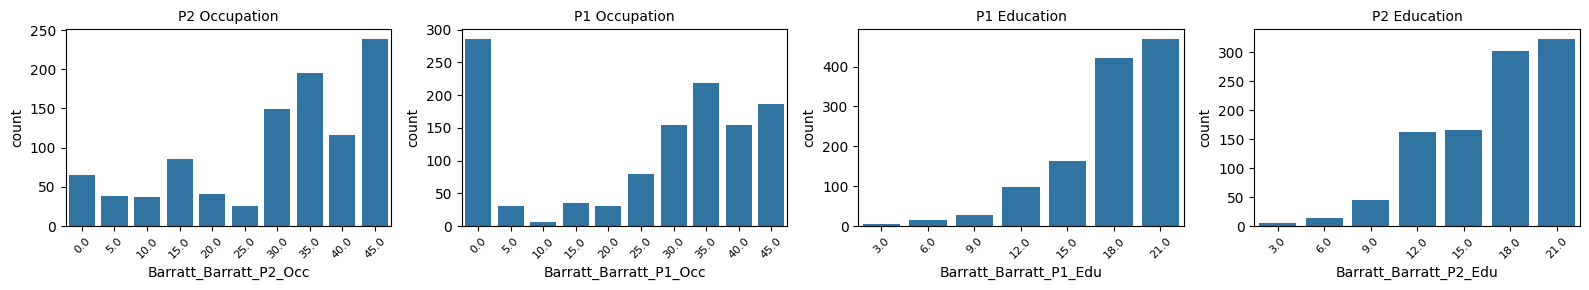

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))  # smaller height

sns.countplot(x='Barratt_Barratt_P2_Occ', data=train_cat, ax=axes[0])
axes[0].set_title("P2 Occupation", fontsize=10)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

sns.countplot(x='Barratt_Barratt_P1_Occ', data=train_cat, ax=axes[1])
axes[1].set_title("P1 Occupation", fontsize=10)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)

sns.countplot(x='Barratt_Barratt_P1_Edu', data=train_cat, ax=axes[2])
axes[2].set_title("P1 Education", fontsize=10)
axes[2].tick_params(axis='x', rotation=45, labelsize=8)

sns.countplot(x='Barratt_Barratt_P2_Edu', data=train_cat, ax=axes[3])
axes[3].set_title("P2 Education", fontsize=10)
axes[3].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()


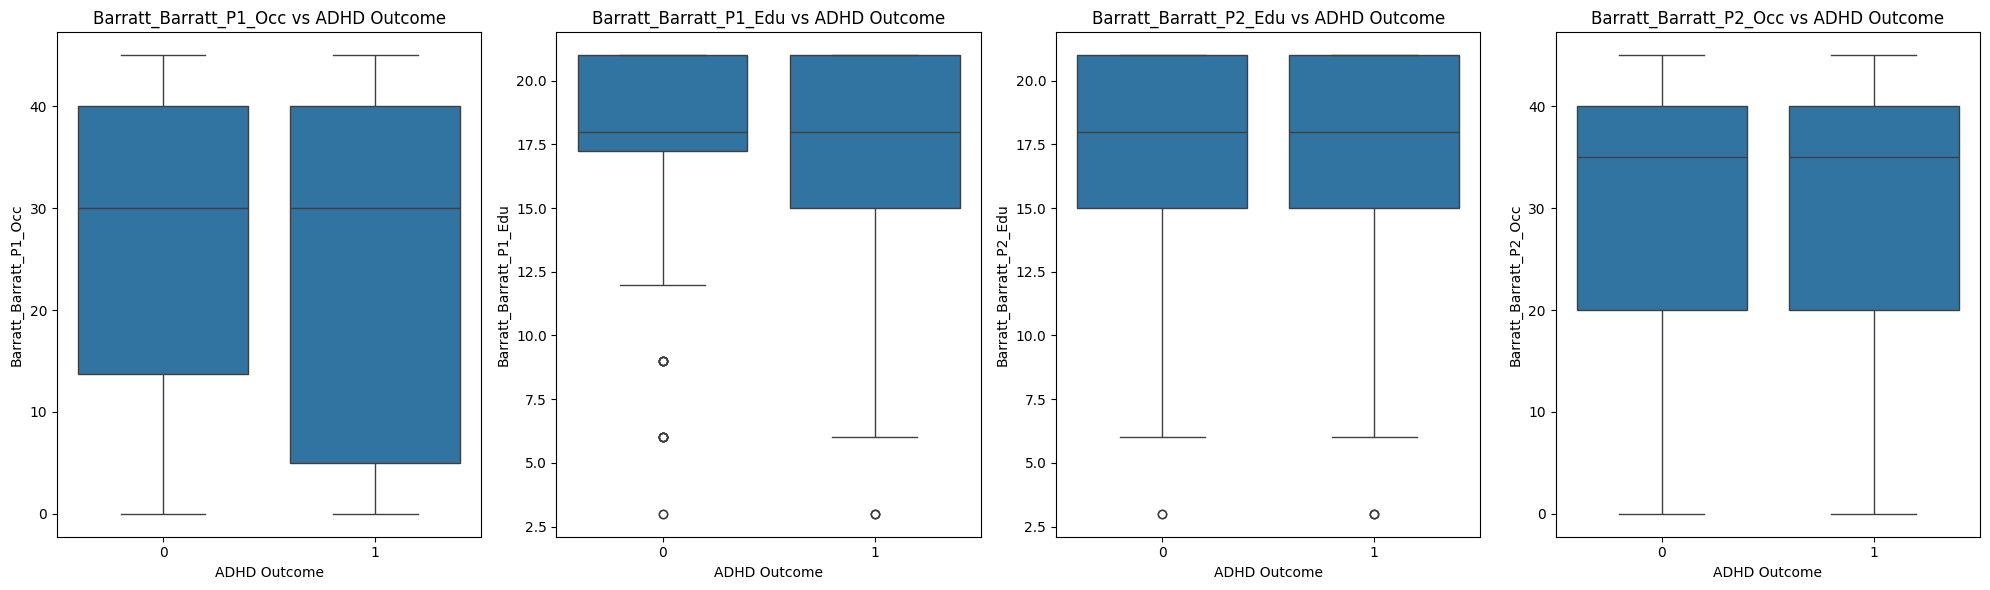

In [ ]:
# Create a 1x4 grid of subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
train_cat_copy = train_cat.copy()
train_cat_copy['ADHD_Outcome'] = train_sol['ADHD_Outcome']
# Plot 1
sns.boxplot(x='ADHD_Outcome', y='Barratt_Barratt_P1_Occ', data=train_cat_copy, ax=axes[0])
axes[0].set_title('Barratt_Barratt_P1_Occ vs ADHD Outcome')
axes[0].set_xlabel('ADHD Outcome')
axes[0].set_ylabel('Barratt_Barratt_P1_Occ')

# Plot 2
sns.boxplot(x='ADHD_Outcome', y='Barratt_Barratt_P1_Edu', data=train_cat_copy, ax=axes[1])
axes[1].set_title('Barratt_Barratt_P1_Edu vs ADHD Outcome')
axes[1].set_xlabel('ADHD Outcome')
axes[1].set_ylabel('Barratt_Barratt_P1_Edu')

# Plot 3
sns.boxplot(x='ADHD_Outcome', y='Barratt_Barratt_P2_Edu', data=train_cat_copy, ax=axes[2])
axes[2].set_title('Barratt_Barratt_P2_Edu vs ADHD Outcome')
axes[2].set_xlabel('ADHD Outcome')
axes[2].set_ylabel('Barratt_Barratt_P2_Edu')

# Plot 4
sns.boxplot(x='ADHD_Outcome', y='Barratt_Barratt_P2_Occ', data=train_cat_copy, ax=axes[3])
axes[3].set_title('Barratt_Barratt_P2_Occ vs ADHD Outcome')
axes[3].set_xlabel('ADHD Outcome')
axes[3].set_ylabel('Barratt_Barratt_P2_Occ')

plt.tight_layout()
plt.show()


In [ ]:
# catagorical data didnt give much insight

In [ ]:
train_quant.head()

,participant_id,EHQ_EHQ_Total,ColorVision_CV_Score,APQ_P_APQ_P_CP,APQ_P_APQ_P_ID,APQ_P_APQ_P_INV,APQ_P_APQ_P_OPD,APQ_P_APQ_P_PM,APQ_P_APQ_P_PP,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,100.00,13.0,3.0,15.0,44.0,14.0,20.0,27.0,3.0,17.0,4.0,11.0,5.0,8.0,6.0,2.0,9.0,14.274127
1,00fV0OyyoLfw,92.27,14.0,3.0,12.0,35.0,25.0,28.0,30.0,5.0,20.0,4.0,13.0,5.0,8.0,7.0,3.0,8.0,NaN
2,04X1eiS79T4B,86.67,14.0,3.0,21.0,37.0,18.0,26.0,28.0,3.0,24.0,7.0,10.0,10.0,7.0,14.0,7.0,7.0,13.463381
3,05ocQutkURd6,93.34,14.0,3.0,11.0,42.0,15.0,20.0,28.0,0.0,5.0,0.0,3.0,0.0,3.0,2.0,2.0,6.0,9.572553
4,06YUNBA9ZRLq,0.00,14.0,8.0,12.0,35.0,22.0,12.0,24.0,6.0,23.0,7.0,15.0,8.0,9.0,8.0,1.0,4.0,6.654574


In [ ]:
# from the dictionary:
'''
EHQ_total: Laterality Index (Score)
CV : Color vision test score
APQ_P_APQ_P_CP : Corporal Punishment Score
APQ_P_APQ_P_ID	: Inconsistent Discipline Score
APQ_P_APQ_P_INV : Involvement Score
APQ_P_APQ_P_OPD	: Other Discipline Practices Score (Not factored into total score but provides item level information)
APQ_P_APQ_P_PM : Poor Monitoring/Supervision Score
APQ_P_APQ_P_PP : Positive Parenting Score
rest are self explanatory
'''

In [ ]:
train_quant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   participant_id              1213 non-null   object 
 1   EHQ_EHQ_Total               1200 non-null   float64
 2   ColorVision_CV_Score        1190 non-null   float64
 3   APQ_P_APQ_P_CP              1201 non-null   float64
 4   APQ_P_APQ_P_ID              1201 non-null   float64
 5   APQ_P_APQ_P_INV             1201 non-null   float64
 6   APQ_P_APQ_P_OPD             1201 non-null   float64
 7   APQ_P_APQ_P_PM              1201 non-null   float64
 8   APQ_P_APQ_P_PP              1201 non-null   float64
 9   SDQ_SDQ_Conduct_Problems    1204 non-null   float64
 10  SDQ_SDQ_Difficulties_Total  1204 non-null   float64
 11  SDQ_SDQ_Emotional_Problems  1204 non-null   float64
 12  SDQ_SDQ_Externalizing       1204 non-null   float64
 13  SDQ_SDQ_Generating_Impact   1204 

In [ ]:
# Last column has a lot of empty cells

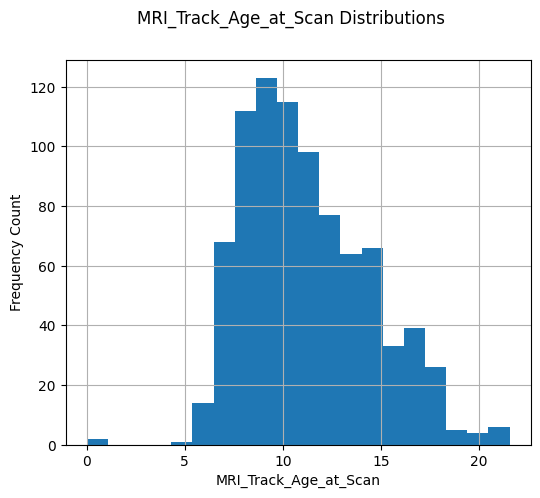

In [ ]:
# Distribution of MRI_Track_Age_at_Scan
train_quant['MRI_Track_Age_at_Scan'].hist(figsize=(6, 5), bins=20)
plt.suptitle("MRI_Track_Age_at_Scan Distributions")
plt.xlabel('MRI_Track_Age_at_Scan')
plt.ylabel('Frequency Count')
plt.show()

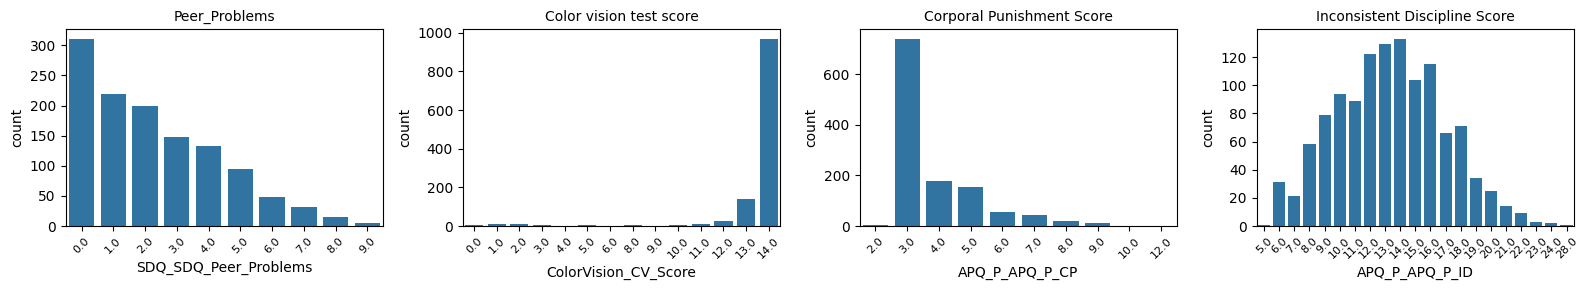

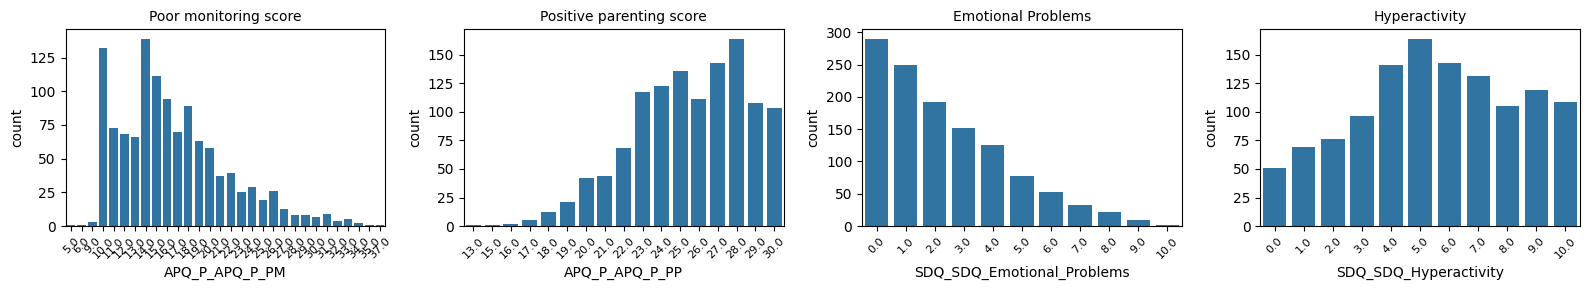

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))  # smaller height

sns.countplot(x='SDQ_SDQ_Peer_Problems', data=train_quant, ax=axes[0])
axes[0].set_title("Peer_Problems", fontsize=10)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

sns.countplot(x='ColorVision_CV_Score', data=train_quant, ax=axes[1])
axes[1].set_title("Color vision test score", fontsize=10)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)

sns.countplot(x='APQ_P_APQ_P_CP', data=train_quant, ax=axes[2])
axes[2].set_title("Corporal Punishment Score", fontsize=10)
axes[2].tick_params(axis='x', rotation=45, labelsize=8)

sns.countplot(x='APQ_P_APQ_P_ID', data=train_quant, ax=axes[3])
axes[3].set_title("Inconsistent Discipline Score", fontsize=10)
axes[3].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 3))  # smaller height

sns.countplot(x='APQ_P_APQ_P_PM', data=train_quant, ax=axes[0])
axes[0].set_title("Poor monitoring score", fontsize=10)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

sns.countplot(x='APQ_P_APQ_P_PP', data=train_quant, ax=axes[1])
axes[1].set_title("Positive parenting score", fontsize=10)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)

sns.countplot(x='SDQ_SDQ_Emotional_Problems', data=train_quant, ax=axes[2])
axes[2].set_title("Emotional Problems", fontsize=10)
axes[2].tick_params(axis='x', rotation=45, labelsize=8)

sns.countplot(x='SDQ_SDQ_Hyperactivity', data=train_quant, ax=axes[3])
axes[3].set_title("Hyperactivity", fontsize=10)
axes[3].tick_params(axis='x', rotation=45, labelsize=8)

plt.tight_layout()
plt.show()

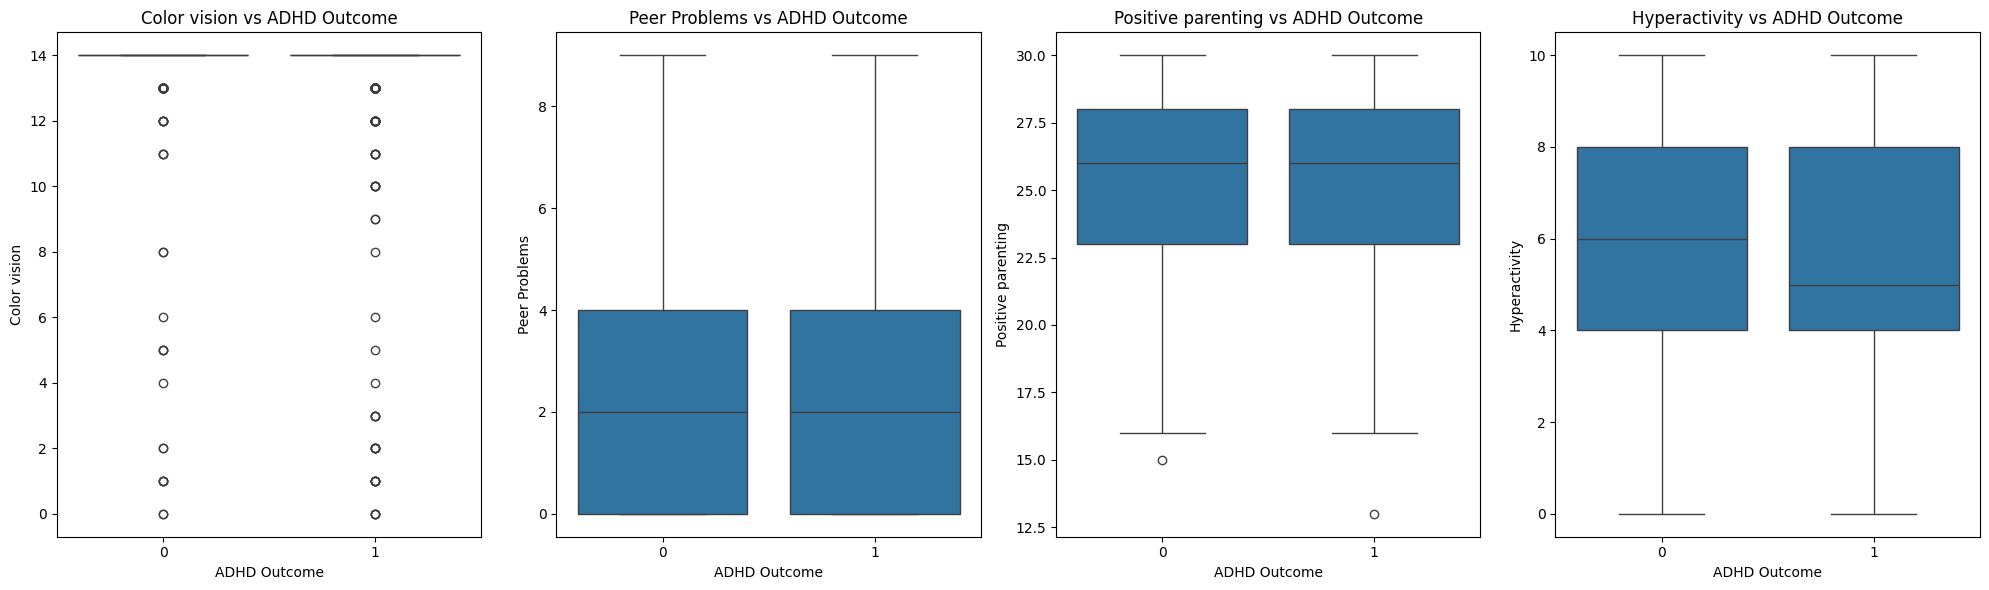

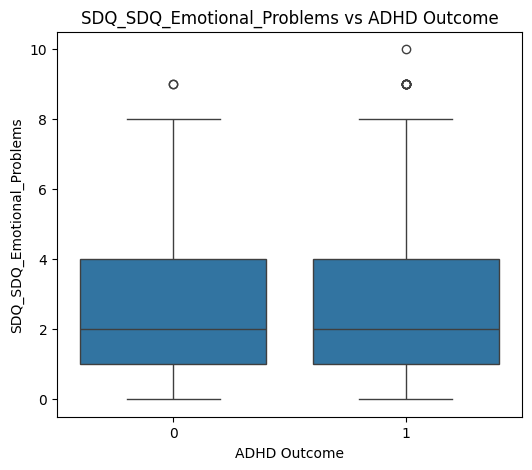

In [ ]:
# Create a 1x4 grid of subplots
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
train_quant_copy = train_quant.copy()
train_quant_copy['ADHD_Outcome'] = train_sol['ADHD_Outcome']
# Plot 1
sns.boxplot(x='ADHD_Outcome', y='ColorVision_CV_Score', data=train_quant_copy, ax=axes[0])
axes[0].set_title('Color vision vs ADHD Outcome')
axes[0].set_xlabel('ADHD Outcome')
axes[0].set_ylabel('Color vision')

# Plot 2
sns.boxplot(x='ADHD_Outcome', y='SDQ_SDQ_Peer_Problems', data=train_quant_copy, ax=axes[1])
axes[1].set_title('Peer Problems vs ADHD Outcome')
axes[1].set_xlabel('ADHD Outcome')
axes[1].set_ylabel('Peer Problems')

# Plot 3
sns.boxplot(x='ADHD_Outcome', y='APQ_P_APQ_P_PP', data=train_quant_copy, ax=axes[2])
axes[2].set_title('Positive parenting vs ADHD Outcome')
axes[2].set_xlabel('ADHD Outcome')
axes[2].set_ylabel('Positive parenting')

# Plot 4
sns.boxplot(x='ADHD_Outcome', y='SDQ_SDQ_Hyperactivity', data=train_quant_copy, ax=axes[3])
axes[3].set_title('Hyperactivity vs ADHD Outcome')
axes[3].set_xlabel('ADHD Outcome')
axes[3].set_ylabel('Hyperactivity')

plt.tight_layout()
plt.show()



plt.figure(figsize=(6, 5))
sns.boxplot(x='ADHD_Outcome', y='SDQ_SDQ_Emotional_Problems', data=train_quant_copy)
plt.title('SDQ_SDQ_Emotional_Problems vs ADHD Outcome')
plt.xlabel('ADHD Outcome')
plt.ylabel('SDQ_SDQ_Emotional_Problems')
plt.show()

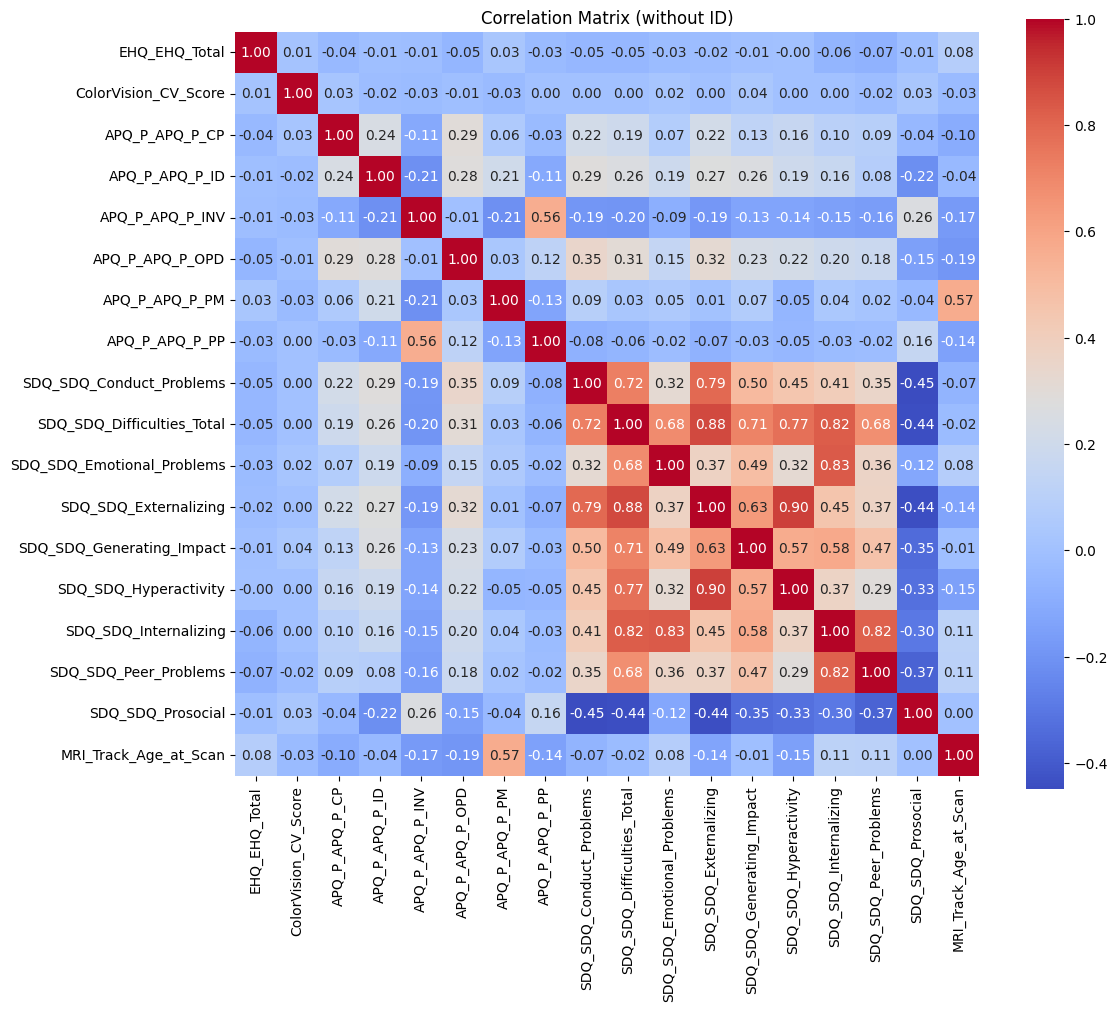

In [ ]:
correlation_matrix = train_quant.drop(columns=['participant_id']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix (without ID)")
plt.show()


Strongly Correlated Features (|r| > 0.7):


,Feature 1,Feature 2,Correlation
7,SDQ_SDQ_Externalizing,SDQ_SDQ_Hyperactivity,0.899
2,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Externalizing,0.877
6,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Internalizing,0.832
5,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Internalizing,0.825
8,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,0.818
1,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Externalizing,0.794
4,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Hyperactivity,0.769
0,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,0.723
3,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Generating_Impact,0.713


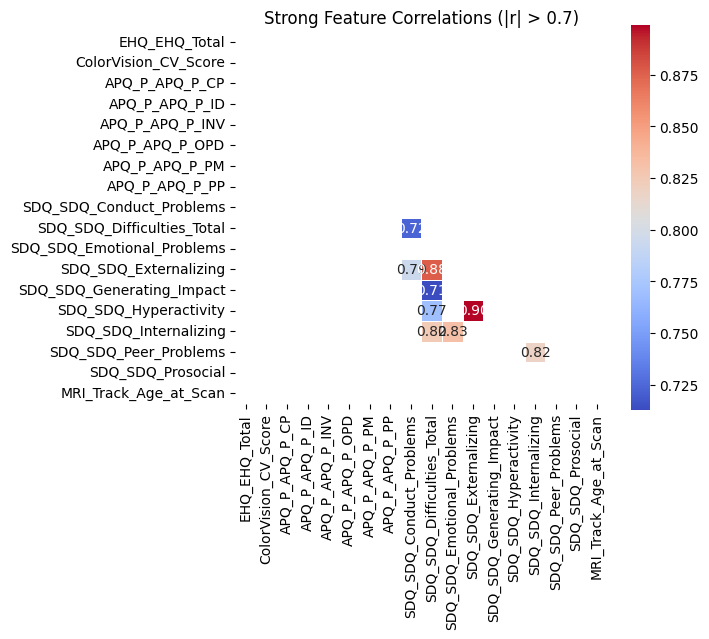

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Calculate correlation (drop ID if exists)
corr = train_quant.drop(columns=['participant_id'], errors='ignore').corr()

# Step 2: Create mask for upper triangle (to avoid duplicates)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Step 3: Filter for strong correlations (abs > 0.7 but < 1.0)
strong_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        value = corr.iloc[i, j]
        if abs(value) > 0.7 and abs(value) < 1.0:  # avoid self-correlation
            strong_pairs.append((corr.columns[i], corr.columns[j], round(value, 3)))

# Step 4: Display as DataFrame
strong_df = pd.DataFrame(strong_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
print("Strongly Correlated Features (|r| > 0.7):")
display(strong_df.sort_values(by='Correlation', key=lambda x: abs(x), ascending=False))

# Step 5: Optional heatmap visualization
strong_corr = corr.copy()
strong_corr[abs(corr) <= 0.7] = np.nan  # remove weak correlations

plt.figure(figsize=(6, 5))
sns.heatmap(strong_corr, annot=True, fmt=".2f", cmap='coolwarm', mask=mask, linewidths=0.5, square=True)
plt.title("Strong Feature Correlations (|r| > 0.7)")
plt.show()


In [ ]:
## target EDA

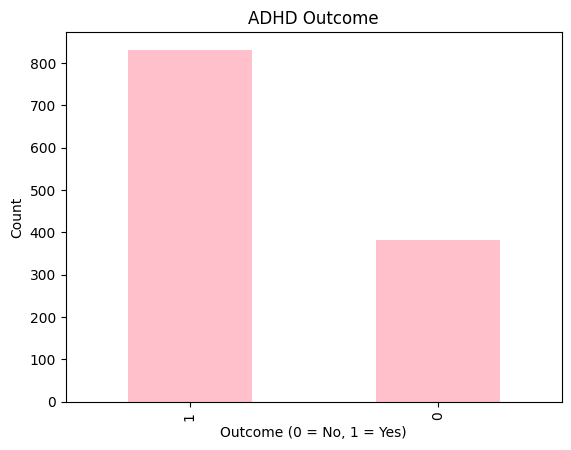

In [ ]:
train_sol['ADHD_Outcome'].value_counts().plot(kind='bar', color='pink')
plt.title('ADHD Outcome')
plt.xlabel('Outcome (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

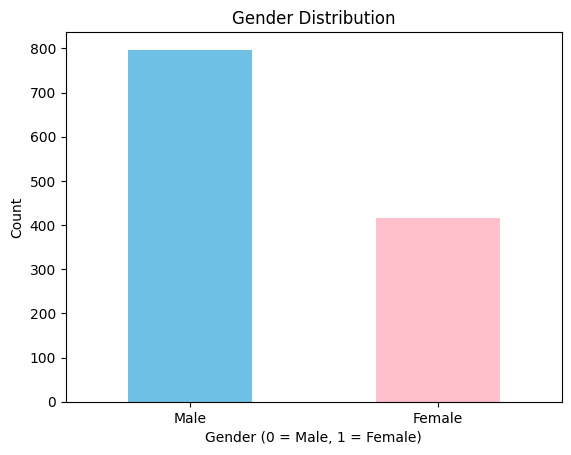

In [ ]:
import matplotlib.pyplot as plt

# Get the value counts (0 = Male, 1 = Female)
gender_counts = train_sol['Sex_F'].value_counts()

# Define custom colors: index 0 → Male, index 1 → Female
colors = ['#6EC1E4' if gender == 0 else 'pink' for gender in gender_counts.index]

# Plot with your aesthetic
gender_counts.plot(kind='bar', color=colors)
plt.title('Gender Distribution')
plt.xlabel('Gender (0 = Male, 1 = Female)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'], rotation=0)
plt.show()


In [ ]:
train_sol.head()

,participant_id,ADHD_Outcome,Sex_F
0,UmrK0vMLopoR,1,1
1,CPaeQkhcjg7d,1,0
2,Nb4EetVPm3gs,1,0
3,p4vPhVu91o4b,1,1
4,M09PXs7arQ5E,1,1


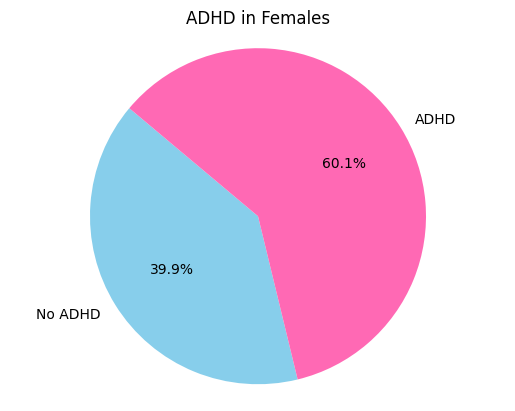

In [ ]:
import matplotlib.pyplot as plt

# Clean column names (if not already done)
train_sol.columns = train_sol.columns.str.strip()

# Filter female data again, just to be safe
females = train_sol[train_sol['Sex_F'] == 1]

# Count ADHD vs non-ADHD
adhd_counts = females['ADHD_Outcome'].value_counts().sort_index()  # [0, 1]

# Labels and colors for the queen energy
labels = ['No ADHD', 'ADHD']
colors = ['skyblue', 'hotpink']

# Plot
plt.pie(adhd_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("ADHD in Females")
plt.axis('equal')
plt.show()

In [ ]:
# view if there are features that strongly affects ADHD outcome
import pandas as pd
import scipy.stats as stats

# Merge the continuous features and ADHD outcome data
train_quant_copy = train_quant.copy()
train_quant_copy['ADHD_Outcome'] = train_sol['ADHD_Outcome']
dropped = train_quant_copy.drop(columns=['participant_id'], errors='ignore')
dropped = dropped.fillna(dropped.mean())
# Compute the point-biserial correlation for each feature
correlations = {}
for column in dropped.columns:
    if column != 'participant_id':  # Exclude Participant_ID from correlation calculation
        corr, _ = stats.pointbiserialr(dropped['ADHD_Outcome'], dropped[column])
        correlations[column] = corr

# Convert the dictionary to a DataFrame for better presentation
correlations_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Point-Biserial Correlation'])
correlations_df = correlations_df.sort_values(by='Point-Biserial Correlation', ascending=False)

print(correlations_df)



                       Feature  Point-Biserial Correlation
18                ADHD_Outcome                    1.000000
17       MRI_Track_Age_at_Scan                    0.030327
8     SDQ_SDQ_Conduct_Problems                    0.019673
0                EHQ_EHQ_Total                    0.018910
6               APQ_P_APQ_P_PM                    0.018724
7               APQ_P_APQ_P_PP                    0.016379
3               APQ_P_APQ_P_ID                    0.011486
1         ColorVision_CV_Score                    0.010748
2               APQ_P_APQ_P_CP                   -0.001499
4              APQ_P_APQ_P_INV                   -0.003508
16           SDQ_SDQ_Prosocial                   -0.007838
15       SDQ_SDQ_Peer_Problems                   -0.008366
12   SDQ_SDQ_Generating_Impact                   -0.009934
10  SDQ_SDQ_Emotional_Problems                   -0.010628
14       SDQ_SDQ_Internalizing                   -0.011538
11       SDQ_SDQ_Externalizing                   -0.0148

In [ ]:
# its obvious that there arent a single feature that is extremely correlated to ADHD diagnosis, hyperactivity and age at scan is show the highest correlation

# **Pre-Processing and Merging**

## ***1- Training datasets***

***Filling and encoding Categorical dataset***

In [10]:
# Fill categorical NaNs with mode per column BEFORE ENCODING
for col in train_cat.columns[1:]:  # skip participant_id
    train_cat[col] = train_cat[col].fillna(train_cat[col].mode()[0])

In [11]:
# one hot encoding for categorical dataframe
for col in train_cat.select_dtypes(include='int').columns:
    train_cat[col] = train_cat[col].astype('category')
for col in train_cat.select_dtypes(include='float').columns:
    train_cat[col] = train_cat[col].astype('category')

In [12]:

# Creating a list of all of the columns except the first (ID)
columns_to_encode = train_cat.columns[1:].tolist()

# Print the columns to encode
print("Columns to encode:", columns_to_encode)

Columns to encode: ['Basic_Demos_Enroll_Year', 'Basic_Demos_Study_Site', 'PreInt_Demos_Fam_Child_Ethnicity', 'PreInt_Demos_Fam_Child_Race', 'MRI_Track_Scan_Location', 'Barratt_Barratt_P1_Edu', 'Barratt_Barratt_P1_Occ', 'Barratt_Barratt_P2_Edu', 'Barratt_Barratt_P2_Occ']


In [13]:
train_encoded = pd.get_dummies(train_cat[columns_to_encode], drop_first=True)
train_encoded = train_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))

<ipython-input-13-e1c7f0efcfb3>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_encoded = train_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))


In [14]:
# Combine encoded columns with the rest of the DataFrame
cat_train_final = pd.concat([train_cat['participant_id'], train_encoded], axis=1)

# ensure it looks correct
cat_train_final.head()

,participant_id,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,PreInt_Demos_Fam_Child_Ethnicity_1.0,...,Barratt_Barratt_P2_Edu_21.0,Barratt_Barratt_P2_Occ_5.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0
0,00aIpNTbG5uh,0,0,0,1,0,0,0,1,1,...,1,0,0,0,0,0,0,0,0,1
1,00fV0OyyoLfw,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,04X1eiS79T4B,0,1,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
3,05ocQutkURd6,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,06YUNBA9ZRLq,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


***Merging***

In [15]:

# Fill NaNs with 0 for numerical columns (except participant_id)
for col in train_FCM.columns[1:]:  # Skip participant_id column
    train_FCM[col] = train_FCM[col].fillna(0)

# Now apply StandardScaler to all columns except participant_id
scaler = StandardScaler()
train_FCM_scaled = train_FCM.copy()  # Create a copy to preserve original
train_FCM_scaled.loc[:, train_FCM.columns != 'participant_id'] = scaler.fit_transform(train_FCM.loc[:, train_FCM.columns != 'participant_id'])

In [16]:
for col in train_quant.columns[1:]:  # skip participant_id
    train_quant[col] = train_quant[col].fillna(train_quant[col].median())

scaler = StandardScaler()
train_quant_scaled = train_quant.copy()  # Create a copy to preserve original
train_quant_scaled.loc[:, train_quant.columns != 'participant_id'] = scaler.fit_transform(train_quant.loc[:, train_quant.columns != 'participant_id'])

In [17]:
train_cat_FCM = pd.merge(cat_train_final, train_FCM_scaled, on = 'participant_id')

In [18]:
train_df = pd.merge(train_cat_FCM, train_quant_scaled, on = 'participant_id')
train_df = train_df.sort_values(by='participant_id')
train_sol = train_sol.sort_values(by='participant_id')
# ensure it looks accurate
train_df.head()

,participant_id,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,PreInt_Demos_Fam_Child_Ethnicity_1.0,...,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,00aIpNTbG5uh,0,0,0,1,0,0,0,1,1,...,0.459537,0.737721,0.777547,0.822504,0.320741,0.879029,0.401785,-0.131157,0.602605,1.168428
1,00fV0OyyoLfw,0,1,0,0,0,0,0,0,0,...,1.452267,1.199939,0.777547,1.308711,0.320741,0.879029,0.687798,0.349487,0.123287,-0.130911
2,04X1eiS79T4B,0,1,0,0,0,0,0,0,1,...,0.459537,1.816231,2.167961,0.579400,2.108694,0.521343,2.689888,2.272059,-0.356031,0.870419
3,05ocQutkURd6,0,0,1,0,0,0,0,0,0,...,-1.029559,-1.111154,-1.076339,-1.122325,-1.467212,-0.909401,-0.742266,-0.131157,-0.835349,-0.559747
4,06YUNBA9ZRLq,0,0,1,0,0,0,0,0,0,...,1.948632,1.662158,2.167961,1.794919,1.393513,1.236715,0.973811,-0.611800,-1.793985,-1.632319


In [19]:
train_sol.head()

,participant_id,ADHD_Outcome,Sex_F
26,00aIpNTbG5uh,1,0
668,00fV0OyyoLfw,1,0
850,04X1eiS79T4B,0,1
972,05ocQutkURd6,0,1
703,06YUNBA9ZRLq,1,0


## ***2- Testing dataset***

In [20]:
# Fill categorical NaNs with mode per column BEFORE ENCODING
for col in test_cat.columns[1:]:  # skip participant_id
    test_cat[col] = test_cat[col].fillna(test_cat[col].mode()[0])

In [45]:
# convert our int variables to categories
for col in test_cat.select_dtypes(include='float').columns:
    test_cat[col] = test_cat[col].astype('category')
for col in test_cat.select_dtypes(include='int').columns:
    test_cat[col] = test_cat[col].astype('category')
# Encode categorical variables in test
test_encoded = pd.get_dummies(test_cat[columns_to_encode], drop_first=True)
test_encoded = test_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))

# Ensure test_encoded has the same columns as train_encoded
missing_cols = set(train_encoded.columns) - set(test_encoded.columns)
for col in missing_cols:
    test_encoded[col] = 0  # Add missing columns with 0 values

# Ensure test_encoded columns are in the same order as train_encoded
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

# Combine encoded columns with the rest of the DataFrame
cat_test_final = pd.concat([test_cat['participant_id'], test_encoded], axis=1)

cat_test_final.head()

<ipython-input-45-f3da1a4a02b9>:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  test_encoded = test_encoded.applymap(lambda x: 1 if x is True else (0 if x is False else x))


,participant_id,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,PreInt_Demos_Fam_Child_Ethnicity_1.0,...,Barratt_Barratt_P2_Edu_21.0,Barratt_Barratt_P2_Occ_5.0,Barratt_Barratt_P2_Occ_10.0,Barratt_Barratt_P2_Occ_15.0,Barratt_Barratt_P2_Occ_20.0,Barratt_Barratt_P2_Occ_25.0,Barratt_Barratt_P2_Occ_30.0,Barratt_Barratt_P2_Occ_35.0,Barratt_Barratt_P2_Occ_40.0,Barratt_Barratt_P2_Occ_45.0
0,Cfwaf5FX7jWK,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,vhGrzmvA3Hjq,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
2,ULliyEXjy4OV,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,LZfeAb1xMtql,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
4,EnFOUv0YK1RG,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1


***Merging***

In [47]:
# Fill NaNs with mode per column BEFORE ENCODING
for col in test_FCM.columns[1:]:  # skip participant_id
    test_FCM[col] = test_FCM[col].fillna(0)
# Now apply StandardScaler to all columns except participant_id
scaler = StandardScaler()
test_FCM_scaled = test_FCM.copy()  # Create a copy to preserve original
test_FCM_scaled.loc[:, test_FCM.columns != 'participant_id'] = scaler.fit_transform(test_FCM.loc[:, test_FCM.columns != 'participant_id'])

In [49]:
for col in test_quant.columns[1:]:  # skip participant_id
    test_quant[col] = test_quant[col].fillna(test_quant[col].median())

In [50]:
test_cat_FCM = pd.merge(cat_test_final, test_FCM_scaled, on = 'participant_id')

test_df = pd.merge(test_cat_FCM, test_quant, on = 'participant_id')

# ensure it looks accurate
test_df.head()

,participant_id,Basic_Demos_Enroll_Year_2016,Basic_Demos_Enroll_Year_2017,Basic_Demos_Enroll_Year_2018,Basic_Demos_Enroll_Year_2019,Basic_Demos_Enroll_Year_2020,Basic_Demos_Study_Site_2,Basic_Demos_Study_Site_3,Basic_Demos_Study_Site_4,PreInt_Demos_Fam_Child_Ethnicity_1.0,...,SDQ_SDQ_Conduct_Problems,SDQ_SDQ_Difficulties_Total,SDQ_SDQ_Emotional_Problems,SDQ_SDQ_Externalizing,SDQ_SDQ_Generating_Impact,SDQ_SDQ_Hyperactivity,SDQ_SDQ_Internalizing,SDQ_SDQ_Peer_Problems,SDQ_SDQ_Prosocial,MRI_Track_Age_at_Scan
0,Cfwaf5FX7jWK,0,0,0,0,0,0,0,0,0,...,2.0,12.0,3.0,9.0,2.0,7.0,3.0,0.0,8.0,8.992813
1,vhGrzmvA3Hjq,0,0,0,0,0,0,0,0,0,...,2.0,16.0,8.0,5.0,7.0,3.0,11.0,3.0,9.0,12.324093
2,ULliyEXjy4OV,0,0,0,0,0,0,0,0,0,...,1.0,7.0,1.0,6.0,1.0,5.0,1.0,0.0,9.0,7.770933
3,LZfeAb1xMtql,0,0,0,0,0,0,0,0,0,...,4.0,15.0,4.0,10.0,8.0,6.0,5.0,1.0,6.0,9.304814
4,EnFOUv0YK1RG,0,0,0,0,0,0,0,0,0,...,2.0,18.0,6.0,12.0,5.0,10.0,6.0,0.0,10.0,8.261350


### **The Models**

Splitting the training set to 85% training and 15% testing to be able to test our model "with given targets"

In [25]:
## cv score might be shit due to NaN filling technique, might need to change that
## also this could be due to the huge number of columns (features), PCA might be needed
## scaling a feature can enhance it as well

In [26]:
from sklearn.model_selection import train_test_split

# Assuming you already have 'X' as your features and 'y' as your multi-target labels
X = train_df.drop(columns=['participant_id'])  # Dropping participant ID
y = train_sol.drop(columns=['participant_id'])  # Labels for ADHD and Gender

# Train-test split (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)


# **Random Forest**

Random forest was tried on the original training dataframe (before balancing), then stratified sampling, then feature selection using selectFromModel, then lastely, PCA

## before balancing


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import cross_val_score # Import cross_val_score

# Initialize Random Forest Classifier with class weights
rf = RandomForestClassifier(class_weight='balanced',random_state=42)

# Initialize MultiOutputClassifier
multi_target_rf = MultiOutputClassifier(rf)

# Train the model
multi_target_rf.fit(X_train, y_train)

cv_scores = cross_val_score(multi_target_rf, X_train, y_train, cv=5, scoring='accuracy')  # Adjust scoring if needed

# Output the cross-validation results
print("Cross-validation scores for each fold:", cv_scores)
print("Mean CV score:", np.mean(cv_scores))

Cross-validation scores for each fold: [0.50241546 0.47087379 0.48543689 0.45145631 0.45631068]
Mean CV score: 0.4732986257680222


In [28]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions
y_pred = multi_target_rf.predict(X_test)

# Evaluation - Classification Report (precision, recall, f1-score for both targets)
print(classification_report(y_test, y_pred))

# Accuracy Score
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix

# ADHD confusion matrix (target 1)
print("Confusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred[:, 0]))

# Gender confusion matrix (target 2)
print("Confusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred[:, 1]))


              precision    recall  f1-score   support

           0       0.67      1.00      0.80       122
           1       0.75      0.05      0.10        56

   micro avg       0.67      0.70      0.69       178
   macro avg       0.71      0.53      0.45       178
weighted avg       0.70      0.70      0.58       178
 samples avg       0.67      0.58      0.61       178

Accuracy on Test Set: 0.4945054945054945
Confusion Matrix for ADHD Target:
[[  0  60]
 [  0 122]]
Confusion Matrix for Gender Target:
[[125   1]
 [ 53   3]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
from sklearn.metrics import classification_report

# Classification report for the first target (ADHD)
print("ADHD Classification Report:")
print(classification_report(y_test.iloc[:, 0], y_pred[:, 0]))

# Classification report for the second target (Gender)
print("Gender Classification Report:")
print(classification_report(y_test.iloc[:, 1], y_pred[:, 1]))


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.67      1.00      0.80       122

    accuracy                           0.67       182
   macro avg       0.34      0.50      0.40       182
weighted avg       0.45      0.67      0.54       182

Gender Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.99      0.82       126
           1       0.75      0.05      0.10        56

    accuracy                           0.70       182
   macro avg       0.73      0.52      0.46       182
weighted avg       0.72      0.70      0.60       182



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## After balancing

In [30]:
##29/04
# Reset index
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# Combine target columns into one group label
y_train_combined = y_train.copy()
y_train_combined['group'] = y_train_combined['Sex_F'].astype(str) + '_' + y_train_combined['ADHD_Outcome'].astype(str)

# Get the minimum class count
min_count = y_train_combined['group'].value_counts().min()

# Sample equally from each group
balanced_indices = (
    y_train_combined.groupby('group', group_keys=False)
    .apply(lambda x: x.sample(n=min_count, random_state=42))
    .index
)
# Print the number of samples in each group after balancing
print("Balanced group counts:")
print(y_train_combined.loc[balanced_indices, 'group'].value_counts())

# Subset the data
X_train_balanced = X_train.loc[balanced_indices].reset_index(drop=True)
y_train_balanced = y_train.loc[balanced_indices].reset_index(drop=True)


Balanced group counts:
group
0_0    145
0_1    145
1_0    145
1_1    145
Name: count, dtype: int64


<ipython-input-30-02d426afa47d>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_count, random_state=42))


In [ ]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import cross_val_score # Import cross_val_score

# Initialize Random Forest Classifier with class weights
rf =RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Initialize MultiOutputClassifier
multi_target_rf = MultiOutputClassifier(rf)

# Train the model
multi_target_rf.fit(X_train_balanced, y_train_balanced)


MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=10,
                                                       min_samples_leaf=2,
                                                       min_samples_split=5,
                                                       random_state=42))

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Predictions
y_pred = multi_target_rf.predict(X_test)

# Evaluation - Classification Report (precision, recall, f1-score for both targets)
print(classification_report(y_test, y_pred))

# Accuracy Score
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix

# ADHD confusion matrix (target 1)
print("Confusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred[:, 0]))

# Gender confusion matrix (target 2)
print("Confusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred[:, 1]))

              precision    recall  f1-score   support

           0       0.76      0.66      0.70       122
           1       0.38      0.59      0.46        56

   micro avg       0.59      0.63      0.61       178
   macro avg       0.57      0.62      0.58       178
weighted avg       0.64      0.63      0.63       178
 samples avg       0.45      0.50      0.46       178

Accuracy on Test Set: 0.3516483516483517
Confusion Matrix for ADHD Target:
[[35 25]
 [42 80]]
Confusion Matrix for Gender Target:
[[71 55]
 [23 33]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import classification_report

# Classification report for the first target (ADHD)
print("ADHD Classification Report:")
print(classification_report(y_test.iloc[:, 0], y_pred[:, 0]))

# Classification report for the second target (Gender)
print("Gender Classification Report:")
print(classification_report(y_test.iloc[:, 1], y_pred[:, 1]))

ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.58      0.51        60
           1       0.76      0.66      0.70       122

    accuracy                           0.63       182
   macro avg       0.61      0.62      0.61       182
weighted avg       0.66      0.63      0.64       182

Gender Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.56      0.65       126
           1       0.38      0.59      0.46        56

    accuracy                           0.57       182
   macro avg       0.57      0.58      0.55       182
weighted avg       0.64      0.57      0.59       182



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Step 1: Feature selection using SelectFromModel (model-based)
rf_adhd = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
sfm_adhd = SelectFromModel(rf_adhd, prefit=True, max_features=5000)
adhd_selected = sfm_adhd.get_support(indices=True)

rf_gender = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
sfm_gender = SelectFromModel(rf_gender, prefit=True, max_features=5000)
gender_selected = sfm_gender.get_support(indices=True)

# Step 2: Combine and deduplicate indices
combined_indices = np.unique(np.concatenate([adhd_selected, gender_selected]))

# Step 3: Apply selected features to train/test sets
X_train_combined = X_train_balanced.iloc[:, combined_indices]
X_test_combined = X_test.iloc[:, combined_indices]

# Step 4: Train MultiOutputClassifier using RandomForest as base
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight='balanced', random_state=42)
multi_target_rf = MultiOutputClassifier(rf_model)
multi_target_rf.fit(X_train_combined, y_train_balanced)

# Step 5: Prediction
y_pred = multi_target_rf.predict(X_test_combined)

# Step 6: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Step 7: Combined Report
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Step 8: Separate ADHD and Gender Reports
y_pred_adhd = y_pred[:, 0]
y_pred_gender = y_pred[:, 1]

print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))

print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))


Accuracy on Test Set: 0.3956043956043956

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.79      0.70      0.74       122
           1       0.39      0.62      0.48        56

   micro avg       0.61      0.68      0.64       178
   macro avg       0.59      0.66      0.61       178
weighted avg       0.66      0.68      0.66       178
 samples avg       0.48      0.53      0.49       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.62      0.56        60
           1       0.79      0.70      0.74       122

    accuracy                           0.68       182
   macro avg       0.65      0.66      0.65       182
weighted avg       0.70      0.68      0.68       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.56      0.65       126
           1       0.39    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import numpy as np

best_k = None
best_accuracy = 0
best_combined_indices = None
accuracies = []

for k in range(10, 150, 1):
    selector_adhd = SelectKBest(score_func=f_classif, k=min(k, X_train_balanced.shape[1]))
    selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
    adhd_indices = selector_adhd.get_support(indices=True)

    selector_gender = SelectKBest(score_func=f_classif, k=min(k, X_train_balanced.shape[1]))
    selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
    gender_indices = selector_gender.get_support(indices=True)

    combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

    X_train_k = X_train_balanced.iloc[:, combined_indices]
    X_test_k = X_test.iloc[:, combined_indices]

    rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)
    multi_rf = MultiOutputClassifier(rf)
    multi_rf.fit(X_train_k, y_train_balanced)
    y_pred = multi_rf.predict(X_test_k)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append((k, acc))

    if acc > best_accuracy:
        best_accuracy = acc
        best_k = k
        best_combined_indices = combined_indices

print(f"Best k for Random Forest: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")


Best k for Random Forest: 28
Best Accuracy: 0.5110


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Step 1: Feature selection for ADHD and Gender targets separately
selector_adhd = SelectKBest(score_func=f_classif, k=28)
selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
adhd_indices = selector_adhd.get_support(indices=True)

selector_gender = SelectKBest(score_func=f_classif, k=28)
selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
gender_indices = selector_gender.get_support(indices=True)

# Step 2: Combine and deduplicate indices
combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

# Step 3: Apply to train/test sets
X_train_combined = X_train_balanced.iloc[:, combined_indices]
X_test_combined = X_test.iloc[:, combined_indices]

# Step 4: Random Forest Model with MultiOutputClassifier
rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)

# Create a MultiOutputClassifier with Random Forest
multi_target_rf = MultiOutputClassifier(rf)

# Fit the model using the balanced training set
multi_target_rf.fit(X_train_combined, y_train_balanced)

# Predict on the test set
y_pred = multi_target_rf.predict(X_test_combined)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Individual classification reports
y_pred_adhd = y_pred[:, 0]
y_pred_gender = y_pred[:, 1]

print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))

# Confusion Matrices
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))


Accuracy on Test Set: 0.510989010989011

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       122
           1       0.44      0.70      0.54        56

   micro avg       0.68      0.80      0.73       178
   macro avg       0.65      0.77      0.69       178
weighted avg       0.73      0.80      0.75       178
 samples avg       0.59      0.64      0.59       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.72      0.70        60
           1       0.86      0.84      0.85       122

    accuracy                           0.80       182
   macro avg       0.78      0.78      0.78       182
weighted avg       0.80      0.80      0.80       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.60      0.69       126
           1       0.44     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# Step 2: Apply PCA (keep enough components to retain ~95% variance)
pca = PCA(n_components=0.95, svd_solver='full')  # or try a fixed number like 300 or 500
X_train_pca = pca.fit_transform(X_train_balanced)
X_test_pca = pca.transform(X_test)

print(f"Original features: {X_train_balanced.shape[1]}")
print(f"Reduced to PCA components: {X_train_pca.shape[1]}")

# Step 3: Train with Random Forest (or use Logistic Regression to compare)
rf = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight='balanced', random_state=42)
multi_rf = MultiOutputClassifier(rf)
multi_rf.fit(X_train_pca, y_train_balanced)

# Step 4: Predict and Evaluate
y_pred = multi_rf.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy on Test Set:", accuracy)

print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Separate reports
y_pred_adhd = y_pred[:, 0]
y_pred_gender = y_pred[:, 1]

print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))

print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))


Original features: 19971
Reduced to PCA components: 471

Accuracy on Test Set: 0.21428571428571427

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.65      0.23      0.34       122
           1       0.37      0.79      0.50        56

   micro avg       0.44      0.40      0.42       178
   macro avg       0.51      0.51      0.42       178
weighted avg       0.56      0.40      0.39       178
 samples avg       0.32      0.30      0.29       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.75      0.45        60
           1       0.65      0.23      0.34       122

    accuracy                           0.40       182
   macro avg       0.49      0.49      0.40       182
weighted avg       0.54      0.40      0.38       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.81

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
''''
Why PCA Didn't Help (and Made It Worse)
PCA is unsupervised:

It reduces dimensionality without knowing the class labels.

That means it may throw away features important for ADHD or gender classification, just because they don’t explain overall variance.

PCA can blend useful signal with noise:

Especially in high-dimensional, sparse, or noisy data like yours (20k features), where only a small subset is likely relevant.

Reducing to 471 components might've compressed too much and lost class-specific information.

Better alternatives are supervised:

Techniques like SelectKBest, SelectFromModel, or Regularized Models (L1/L2 Logistic Regression) are aware of the target.

These are better suited for your case, where only some features matter for each target.


# **Logistic regression**

Comparing between L1 and L2

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Define the Logistic Regression model with L1 regularization
log_reg = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)

# Create a MultiOutputClassifier with Logistic Regression
multi_target_log_reg = MultiOutputClassifier(log_reg)

# Fit the model using the balanced training set
multi_target_log_reg.fit(X_train_balanced, y_train_balanced)

# Predict on the test set
y_pred = multi_target_log_reg.predict(X_test)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Use the correct column names from y_test: 'ADHD_Outcome' and 'Sex_F'
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))

Accuracy on Test Set: 0.3901098901098901

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.82      0.69      0.75       122
           1       0.42      0.73      0.54        56

   micro avg       0.63      0.70      0.66       178
   macro avg       0.62      0.71      0.64       178
weighted avg       0.70      0.70      0.68       178
 samples avg       0.49      0.55      0.50       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.70      0.60        60
           1       0.82      0.69      0.75       122

    accuracy                           0.69       182
   macro avg       0.67      0.69      0.68       182
weighted avg       0.73      0.69      0.70       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.56      0.66       126
           1       0.42    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Define the Logistic Regression model with L1 regularization
log_reg = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)

# Create a MultiOutputClassifier with Logistic Regression
multi_target_log_reg = MultiOutputClassifier(log_reg)

# Fit the model using the balanced training set
multi_target_log_reg.fit(X_train_balanced, y_train_balanced)

# Predict on the test set
y_pred = multi_target_log_reg.predict(X_test)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Use the correct column names from y_test: 'ADHD_Outcome' and 'Sex_F'
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))

Accuracy on Test Set: 0.4340659340659341

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.76      0.57      0.65       122
           1       0.49      0.82      0.61        56

   micro avg       0.62      0.65      0.64       178
   macro avg       0.63      0.70      0.63       178
weighted avg       0.68      0.65      0.64       178
 samples avg       0.47      0.49      0.46       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.63      0.51        60
           1       0.76      0.57      0.65       122

    accuracy                           0.59       182
   macro avg       0.59      0.60      0.58       182
weighted avg       0.65      0.59      0.61       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.62      0.73       126
           1       0.49    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Define the Logistic Regression model with L1 regularization
log_reg = LogisticRegression(penalty='l1', solver='saga', max_iter=1000)

# Create a MultiOutputClassifier with Logistic Regression
multi_target_log_reg = MultiOutputClassifier(log_reg)

# Fit the model using the balanced training set
multi_target_log_reg.fit(X_train_balanced, y_train_balanced)

# Predict on the test set
y_pred = multi_target_log_reg.predict(X_test)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Use the correct column names from y_test: 'ADHD_Outcome' and 'Sex_F'
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy on Test Set: 0.4175824175824176

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.76      0.59      0.66       122
           1       0.45      0.73      0.56        56

   micro avg       0.61      0.63      0.62       178
   macro avg       0.60      0.66      0.61       178
weighted avg       0.66      0.63      0.63       178
 samples avg       0.46      0.48      0.45       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.62      0.50        60
           1       0.76      0.59      0.66       122

    accuracy                           0.60       182
   macro avg       0.59      0.60      0.58       182
weighted avg       0.65      0.60      0.61       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.60      0.70       126
           1       0.45    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Determining best C

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define your multi-output logistic regression model
multi_target_log_reg = MultiOutputClassifier(LogisticRegression(max_iter=1000, solver='liblinear'))

# Define the parameter grid for 'C' in logistic regression
param_grid = {'estimator__C': [0.1, 1, 10, 100]} # changed logisticregression__C to estimator__C

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(multi_target_log_reg, param_grid, cv=5, scoring='accuracy')

# Fit the model using the balanced training data
grid_search.fit(X_train_balanced, y_train_balanced)

# Print the best parameters (value of 'C')
print("Best Parameters:", grid_search.best_params_)

# Use the best model to make predictions
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Continue with your classification report or confusion matrix
# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Use the correct column names from y_test: 'ADHD_Outcome' and 'Sex_F'
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))

Best Parameters: {'estimator__C': 0.1}
Accuracy on Test Set: 0.4175824175824176

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.75      0.57      0.64       122
           1       0.48      0.80      0.60        56

   micro avg       0.62      0.64      0.63       178
   macro avg       0.62      0.68      0.62       178
weighted avg       0.67      0.64      0.63       178
 samples avg       0.46      0.48      0.46       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.62      0.49        60
           1       0.75      0.57      0.64       122

    accuracy                           0.58       182
   macro avg       0.58      0.59      0.57       182
weighted avg       0.64      0.58      0.59       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.62      0.7

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
from sklearn.model_selection import GridSearchCV

# Define your multi-output logistic regression model
multi_target_log_reg = MultiOutputClassifier(LogisticRegression(max_iter=1000, solver='liblinear'))

# Define the parameter grid for 'C' in logistic regression
param_grid = {'estimator__C': [0.05,0.02,0.1,0.07,0.2,0.5]} # changed logisticregression__C to estimator__C

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(multi_target_log_reg, param_grid, cv=5, scoring='accuracy')

# Fit the model using the balanced training data
grid_search.fit(X_train_balanced, y_train_balanced)

# Print the best parameters (value of 'C')
print("Best Parameters:", grid_search.best_params_)

# Use the best model to make predictions
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Continue with your classification report or confusion matrix
# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Use the correct column names from y_test: 'ADHD_Outcome' and 'Sex_F'
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))

Best Parameters: {'estimator__C': 0.05}
Accuracy on Test Set: 0.4230769230769231

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.75      0.57      0.65       122
           1       0.48      0.79      0.59        56

   micro avg       0.62      0.64      0.63       178
   macro avg       0.62      0.68      0.62       178
weighted avg       0.67      0.64      0.63       178
 samples avg       0.46      0.49      0.46       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.62      0.50        60
           1       0.75      0.57      0.65       122

    accuracy                           0.59       182
   macro avg       0.58      0.60      0.57       182
weighted avg       0.64      0.59      0.60       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.62      0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Define the Logistic Regression model with L1 regularization
log_reg = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, C=0.05)

# Create a MultiOutputClassifier with Logistic Regression
multi_target_log_reg = MultiOutputClassifier(log_reg)

# Fit the model using the balanced training set
multi_target_log_reg.fit(X_train_balanced, y_train_balanced)

# Predict on the test set
y_pred = multi_target_log_reg.predict(X_test)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Use the correct column names from y_test: 'ADHD_Outcome' and 'Sex_F'
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))

Accuracy on Test Set: 0.45604395604395603

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       122
           1       0.42      0.73      0.54        56

   micro avg       0.66      0.73      0.69       178
   macro avg       0.65      0.73      0.67       178
weighted avg       0.74      0.73      0.72       178
 samples avg       0.53      0.58      0.53       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.80      0.68        60
           1       0.88      0.73      0.80       122

    accuracy                           0.75       182
   macro avg       0.74      0.76      0.74       182
weighted avg       0.79      0.75      0.76       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.56      0.66       126
           1       0.42   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Define the Logistic Regression model with L1 regularization
log_reg = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000, C=0.05)

# Create a MultiOutputClassifier with Logistic Regression
multi_target_log_reg = MultiOutputClassifier(log_reg)

# Fit the model using the balanced training set
multi_target_log_reg.fit(X_train_balanced, y_train_balanced)

# Predict on the test set
y_pred = multi_target_log_reg.predict(X_test)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Use the correct column names from y_test: 'ADHD_Outcome' and 'Sex_F'
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))

Accuracy on Test Set: 0.4230769230769231

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.75      0.57      0.65       122
           1       0.48      0.79      0.59        56

   micro avg       0.62      0.64      0.63       178
   macro avg       0.62      0.68      0.62       178
weighted avg       0.67      0.64      0.63       178
 samples avg       0.46      0.49      0.46       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.62      0.50        60
           1       0.75      0.57      0.65       122

    accuracy                           0.59       182
   macro avg       0.58      0.60      0.57       182
weighted avg       0.64      0.59      0.60       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.62      0.72       126
           1       0.48    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))




```
Trying Feature selection
```



In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
import numpy as np

# Step 1: Fit selectors separately
selector_adhd = SelectKBest(score_func=f_classif, k=5000)
selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
adhd_indices = selector_adhd.get_support(indices=True)

selector_gender = SelectKBest(score_func=f_classif, k=5000)
selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
gender_indices = selector_gender.get_support(indices=True)

# Step 2: Combine and deduplicate indices
combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

# Step 3: Apply to train/test sets
X_train_combined = X_train_balanced.iloc[:, combined_indices]
X_test_combined = X_test.iloc[:, combined_indices]

# Now you can train and test

log_reg = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, C=0.05)

# Create a MultiOutputClassifier with Logistic Regression
multi_target_log_reg = MultiOutputClassifier(log_reg)

# Fit the model using the balanced training set
multi_target_log_reg.fit(X_train_combined, y_train_balanced)

# Predict on the test set
y_pred = multi_target_log_reg.predict(X_test_combined)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Use the correct column names from y_test: 'ADHD_Outcome' and 'Sex_F'
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))


Accuracy on Test Set: 0.45604395604395603

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       122
           1       0.42      0.73      0.54        56

   micro avg       0.66      0.73      0.69       178
   macro avg       0.65      0.73      0.67       178
weighted avg       0.74      0.73      0.72       178
 samples avg       0.53      0.58      0.53       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.80      0.68        60
           1       0.88      0.73      0.80       122

    accuracy                           0.75       182
   macro avg       0.74      0.76      0.74       182
weighted avg       0.79      0.75      0.76       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.56      0.66       126
           1       0.42   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
## smaller k

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np

# Step 1: Fit selectors separately
selector_adhd = SelectKBest(score_func=f_classif, k=57)
selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
adhd_indices = selector_adhd.get_support(indices=True)

selector_gender = SelectKBest(score_func=f_classif, k=57)
selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
gender_indices = selector_gender.get_support(indices=True)

# Step 2: Combine and deduplicate indices
combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

# Step 3: Apply to train/test sets
X_train_combined = X_train_balanced.iloc[:, combined_indices]
X_test_combined = X_test.iloc[:, combined_indices]

# Now you can train and test

log_reg = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, C=0.05)

# Create a MultiOutputClassifier with Logistic Regression
multi_target_log_reg = MultiOutputClassifier(log_reg)

# Fit the model using the balanced training set
multi_target_log_reg.fit(X_train_combined, y_train_balanced)

# Predict on the test set
y_pred = multi_target_log_reg.predict(X_test_combined)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Use the correct column names from y_test: 'ADHD_Outcome' and 'Sex_F'
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))

def multi_output_accuracy(y_true, y_pred):
    # Ensure y_true and y_pred are NumPy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Compute accuracy for each target variable and return the mean
    return np.mean([accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])])
# Create a scorer using scikit-learn's make_scorer
multi_output_scorer = make_scorer(multi_output_accuracy)
# Perform cross-validation on the training data
cv_scores_2 = cross_val_score(multi_target_log_reg, X_train_combined, y_train_balanced, cv=5, scoring=multi_output_scorer, n_jobs=-1)

# Output the cross-validation results
print("Cross-validation scores for each fold:", cv_scores_2)
print("Mean CV score:", np.mean(cv_scores_2))

Accuracy on Test Set: 0.46153846153846156

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.88      0.74      0.80       122
           1       0.42      0.70      0.52        56

   micro avg       0.66      0.72      0.69       178
   macro avg       0.65      0.72      0.66       178
weighted avg       0.74      0.72      0.72       178
 samples avg       0.54      0.59      0.54       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.80      0.69        60
           1       0.88      0.74      0.80       122

    accuracy                           0.76       182
   macro avg       0.74      0.77      0.74       182
weighted avg       0.79      0.76      0.76       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.57      0.67       126
           1       0.42   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Cross-validation scores for each fold: [0.4612069  0.60344828 0.69396552 0.61206897 0.46551724]
Mean CV score: 0.5672413793103448


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import numpy as np

best_k = None
best_accuracy = 0
best_combined_indices = None
accuracies = []

# Try multiple values of k
for k in range(10, 100, 1):
    # Feature selection for both targets
    selector_adhd = SelectKBest(score_func=f_classif, k=min(k, X_train_balanced.shape[1]))
    selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
    adhd_indices = selector_adhd.get_support(indices=True)

    selector_gender = SelectKBest(score_func=f_classif, k=min(k, X_train_balanced.shape[1]))
    selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
    gender_indices = selector_gender.get_support(indices=True)

    # Combine and deduplicate indices
    combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

    # Subset the data
    X_train_k = X_train_balanced.iloc[:, combined_indices]
    X_test_k = X_test.iloc[:, combined_indices]

    # Train Logistic Regression with MultiOutputClassifier
    logreg = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, C=0.05)
    multi_logreg = MultiOutputClassifier(logreg)
    multi_logreg.fit(X_train_k, y_train_balanced)
    y_pred = multi_logreg.predict(X_test_k)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    accuracies.append((k, acc))

    if acc > best_accuracy:
        best_accuracy = acc
        best_k = k
        best_combined_indices = combined_indices

print(f"Best k: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")



Best k: 45
Best Accuracy: 0.4890


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, accuracy_score
import numpy as np

# Step 1: Fit selectors separately
selector_adhd = SelectKBest(score_func=f_classif, k=45)
selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
adhd_indices = selector_adhd.get_support(indices=True)

selector_gender = SelectKBest(score_func=f_classif, k=45)
selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
gender_indices = selector_gender.get_support(indices=True)

# Step 2: Combine and deduplicate indices
combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

# Step 3: Apply to train/test sets
X_train_combined = X_train_balanced.iloc[:, combined_indices]
X_test_combined = X_test.iloc[:, combined_indices]

# Now you can train and test

log_reg = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, C=0.05)

# Create a MultiOutputClassifier with Logistic Regression
multi_target_log_reg = MultiOutputClassifier(log_reg)

# Fit the model using the balanced training set
multi_target_log_reg.fit(X_train_combined, y_train_balanced)

# Predict on the test set
y_pred = multi_target_log_reg.predict(X_test_combined)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Use the correct column names from y_test: 'ADHD_Outcome' and 'Sex_F'
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))

def multi_output_accuracy(y_true, y_pred):
    # Ensure y_true and y_pred are NumPy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Compute accuracy for each target variable and return the mean
    return np.mean([accuracy_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])])
# Create a scorer using scikit-learn's make_scorer
multi_output_scorer = make_scorer(multi_output_accuracy)
# Perform cross-validation on the training data
cv_scores_2 = cross_val_score(multi_target_log_reg, X_train_combined, y_train_balanced, cv=5, scoring=multi_output_scorer, n_jobs=-1)

# Output the cross-validation results
print("Cross-validation scores for each fold:", cv_scores_2)
print("Mean CV score:", np.mean(cv_scores_2))

Accuracy on Test Set: 0.489010989010989

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.89      0.71      0.79       122
           1       0.44      0.66      0.53        56

   micro avg       0.68      0.70      0.69       178
   macro avg       0.66      0.69      0.66       178
weighted avg       0.75      0.70      0.71       178
 samples avg       0.54      0.56      0.53       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.82      0.68        60
           1       0.89      0.71      0.79       122

    accuracy                           0.75       182
   macro avg       0.74      0.76      0.74       182
weighted avg       0.79      0.75      0.75       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.63      0.71       126
           1       0.44     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Cross-validation scores for each fold: [0.47413793 0.59051724 0.72413793 0.625      0.45258621]
Mean CV score: 0.5732758620689655


In [ ]:
##PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Apply PCA (retain 95% variance)
pca = PCA(n_components=0.95, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_balanced)
X_test_pca = pca.transform(X_test)

print(f"Original features: {X_train_balanced.shape[1]}")
print(f"Reduced to PCA components: {X_train_pca.shape[1]}")

# Step 2: Define Logistic Regression (with L1 regularization)
log_reg = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000,
    C=0.05,
    class_weight='balanced'
)

# Step 3: Wrap it for multi-output
multi_target_log_reg = MultiOutputClassifier(log_reg)

# Step 4: Fit on PCA-transformed data
multi_target_log_reg.fit(X_train_pca, y_train_balanced)

# Step 5: Predict and evaluate
y_pred = multi_target_log_reg.predict(X_test_pca)

# Accuracy and reports
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy on Test Set:", accuracy)

print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Per target analysis
y_pred_adhd = y_pred[:, 0]
y_pred_gender = y_pred[:, 1]

print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))

print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))


Original features: 19971
Reduced to PCA components: 471

Accuracy on Test Set: 0.41208791208791207

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.73      0.57      0.64       122
           1       0.46      0.68      0.55        56

   micro avg       0.60      0.61      0.61       178
   macro avg       0.59      0.63      0.59       178
weighted avg       0.64      0.61      0.61       178
 samples avg       0.46      0.46      0.45       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.57      0.47        60
           1       0.73      0.57      0.64       122

    accuracy                           0.57       182
   macro avg       0.56      0.57      0.55       182
weighted avg       0.62      0.57      0.58       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.82

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Decision Trees**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define base Decision Tree with balanced class weights
base_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Wrap it in MultiOutputClassifier
multi_target_dt = MultiOutputClassifier(base_dt)

# Define parameter grid for tuning
param_grid = {
    'estimator__max_depth': [5, 10, 20, None],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 5],
    'estimator__max_features': [None, 'sqrt', 'log2']
}

# Grid search with 3-fold cross-validation (you can increase to 5 for more thorough tuning)
grid_search = GridSearchCV(
    estimator=multi_target_dt,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train_combined, y_train_balanced)

# Best estimator
best_model = grid_search.best_estimator_

# Predict
y_pred = best_model.predict(X_test_combined)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Classification reports
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred[:, 0]))

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred[:, 1]))

# Confusion matrices
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred[:, 0]))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred[:, 1]))

# Show best parameters
print("\nBest Hyperparameters Found:", grid_search.best_params_)


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Accuracy on Test Set: 0.34065934065934067

ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.47      0.49        60
           1       0.75      0.79      0.77       122

    accuracy                           0.68       182
   macro avg       0.63      0.63      0.63       182
weighted avg       0.67      0.68      0.68       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.38      0.51       126
           1       0.36      0.77      0.49        56

    accuracy                           0.50       182
   macro avg       0.57      0.57      0.50       182
weighted avg       0.65      0.50      0.50       182


Confusion Matrix for ADHD Target:
[[28 32]
 [26 96]]

Confusion Matrix for Gender Target:
[[48 78]
 [13 43]]

Best Hyperparameters Found: {'estimator__max_depth': 5, 'estimator__ma

In [ ]:
# feature selection

In [39]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import numpy as np

best_k = None
best_accuracy = 0
best_combined_indices = None
accuracies = []

# Try multiple values of k
for k in range(10, 100, 1):
    selector_adhd = SelectKBest(score_func=f_classif, k=min(k, X_train_balanced.shape[1]))
    selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
    adhd_indices = selector_adhd.get_support(indices=True)

    selector_gender = SelectKBest(score_func=f_classif, k=min(k, X_train_balanced.shape[1]))
    selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
    gender_indices = selector_gender.get_support(indices=True)

    combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

    X_train_k = X_train_balanced.iloc[:, combined_indices]
    X_test_k = X_test.iloc[:, combined_indices]

    # Use tuned hyperparameters
    tree = DecisionTreeClassifier(
        max_depth=5,
        max_features='log2',
        min_samples_leaf=5,
        min_samples_split=2,
        random_state=42
    )

    multi_tree = MultiOutputClassifier(tree)
    multi_tree.fit(X_train_k, y_train_balanced)
    y_pred = multi_tree.predict(X_test_k)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append((k, acc))

    if acc > best_accuracy:
        best_accuracy = acc
        best_k = k
        best_combined_indices = combined_indices

print(f"Best k for Decision Tree: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")


Best k for Decision Tree: 35
Best Accuracy: 0.4505


In [40]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Step 1: Feature selection for ADHD and Gender targets separately
selector_adhd = SelectKBest(score_func=f_classif, k=35)
selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
adhd_indices = selector_adhd.get_support(indices=True)

selector_gender = SelectKBest(score_func=f_classif, k=35)
selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
gender_indices = selector_gender.get_support(indices=True)

# Step 2: Combine and deduplicate indices
combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

# Step 3: Apply to train/test sets
X_train_combined = X_train_balanced.iloc[:, combined_indices]
X_test_combined = X_test.iloc[:, combined_indices]

# Step 4: Decision Tree Model with tuned hyperparameters
dt = DecisionTreeClassifier(
    max_depth=5,
    max_features='log2',
    min_samples_leaf=5,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)

# MultiOutputClassifier wrapper
multi_target_dt = MultiOutputClassifier(dt)

# Train model
multi_target_dt.fit(X_train_combined, y_train_balanced)

# Predict on the test set
y_pred = multi_target_dt.predict(X_test_combined)

# Evaluate results
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Split predictions
y_pred_adhd = y_pred[:, 0]
y_pred_gender = y_pred[:, 1]

print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))

print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))


Accuracy on Test Set: 0.45054945054945056

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.86      0.75      0.80       122
           1       0.38      0.57      0.46        56

   micro avg       0.65      0.69      0.67       178
   macro avg       0.62      0.66      0.63       178
weighted avg       0.71      0.69      0.69       178
 samples avg       0.51      0.55      0.51       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.75      0.66        60
           1       0.86      0.75      0.80       122

    accuracy                           0.75       182
   macro avg       0.73      0.75      0.73       182
weighted avg       0.77      0.75      0.75       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.59      0.66       126
           1       0.38   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Define base KNN estimator
knn = KNeighborsClassifier()

# Wrap in MultiOutputClassifier
multi_knn = MultiOutputClassifier(knn)

# Define hyperparameter grid
param_grid = {
    'estimator__n_neighbors': [3, 5, 7, 9, 11],
    'estimator__weights': ['uniform', 'distance'],
    'estimator__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

# Grid search with 3-fold CV
grid_search = GridSearchCV(multi_knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_balanced, y_train_balanced)

# Best model
best_model = grid_search.best_estimator_

# Predict
y_pred = best_model.predict(X_test)

# Evaluate
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))

# ADHD
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred[:, 0])) # Changed y_test[:, 0] to y_test['ADHD_Outcome']
print("Confusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred[:, 0])) # Changed y_test[:, 0] to y_test['ADHD_Outcome']


# Gender
print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred[:, 1])) # Changed y_test[:, 1] to y_test['Sex_F']
print("Confusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred[:, 1])) # Changed y_test[:, 1] to y_test['Sex_F']


# Best hyperparameters
print("\nBest Hyperparameters Found:", grid_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Accuracy on Test Set: 0.24175824175824176

ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.72      0.43        60
           1       0.59      0.20      0.29       122

    accuracy                           0.37       182
   macro avg       0.45      0.46      0.36       182
weighted avg       0.49      0.37      0.34       182

Confusion Matrix for ADHD Target:
[[43 17]
 [98 24]]

Gender Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.62      0.67       126
           1       0.37      0.50      0.42        56

    accuracy                           0.58       182
   macro avg       0.55      0.56      0.55       182
weighted avg       0.62      0.58      0.60       182

Confusion Matrix for Gender Target:
[[78 48]
 [28 28]]

Best Hyperparameters Found: {'estimator__n_neighbors': 3, 'estimator__p':

In [ ]:
# PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.multioutput import MultiOutputClassifier # Import MultiOutputClassifier

# PCA: Reduce features to 500 components (you can tune this based on your results)
pca = PCA(n_components=500)
X_train_pca = pca.fit_transform(X_train_balanced)
X_test_pca = pca.transform(X_test)

# KNN with PCA-reduced features
knn_pca = KNeighborsClassifier()

# Wrap knn_pca in MultiOutputClassifier to handle multiple targets
multi_knn_pca = MultiOutputClassifier(knn_pca)

# Hyperparameter tuning for KNN (using PCA features) - for both targets
param_grid_pca = {
    'estimator__n_neighbors': [5, 7, 9, 11],
    'estimator__p': [1, 2],
    'estimator__weights': ['uniform', 'distance']
}

grid_search_pca = GridSearchCV(multi_knn_pca, param_grid_pca, cv=5, verbose=2) # Use multi_knn_pca here
grid_search_pca.fit(X_train_pca, y_train_balanced)  # Fit on both targets

# Best hyperparameters for PCA-based KNN
print("Best Hyperparameters for PCA KNN:", grid_search_pca.best_params_)

# Evaluate on the test set
y_pred_pca = grid_search_pca.predict(X_test_pca)

# Output results for ADHD target
print("Accuracy on Test Set (PCA):", accuracy_score(y_test, y_pred_pca)) # Now y_pred_pca has both targets
print("\nClassification Report (PCA - ADHD):")
print(classification_report(y_test['ADHD_Outcome'], y_pred_pca[:, 0])) # Access ADHD predictions

# Confusion matrix for ADHD target
print("\nConfusion Matrix for ADHD (PCA):")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_pca[:, 0])) # Access ADHD predictions

# Output results for Gender target
print("\nClassification Report (PCA - Gender):")
print(classification_report(y_test['Sex_F'], y_pred_pca[:, 1])) # Access Gender predictions

# Confusion matrix for Gender target
print("\nConfusion Matrix for Gender (PCA):")
print(confusion_matrix(y_test['Sex_F'], y_pred_pca[:, 1])) # Access Gender predictions

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END estimator__n_neighbors=5, estimator__p=1, estimator__weights=uniform; total time=   0.1s
[CV] END estimator__n_neighbors=5, estimator__p=1, estimator__weights=uniform; total time=   0.1s
[CV] END estimator__n_neighbors=5, estimator__p=1, estimator__weights=uniform; total time=   0.1s
[CV] END estimator__n_neighbors=5, estimator__p=1, estimator__weights=distance; total time=   0.1s
[CV] END estimator__n_neighbors=5, estimator__p=1, estimator__weights=distance; total time=   0.1s
[CV] END estimator__n_neighbors=5, estimator__p=1, estimator__weights=distance; total time=   0.1s
[CV] END estimator__n_neighbors=5, estimator__p=2, estimator__weights=uniform; total time=   0.0s
[CV] END estimator__n_neighbors=5, estimator__p=2, estimator__weights=uniform; total time=   0.0s
[CV] END estimator__n_neighbors=5, estimator__p=2, estimator__weights=uniform; total time=   0.0s
[CV] END estimator__n_neighbors=5, estimator__p=2, est

In [ ]:
#feature selection

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Step 1: Feature selection for ADHD and Gender targets separately
selector_adhd = SelectKBest(score_func=f_classif, k=60)
selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
adhd_indices = selector_adhd.get_support(indices=True)

selector_gender = SelectKBest(score_func=f_classif, k=60)
selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
gender_indices = selector_gender.get_support(indices=True)

# Step 2: Combine and deduplicate indices
combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

# Step 3: Apply to train/test sets
X_train_combined = X_train_balanced.iloc[:, combined_indices]
X_test_combined = X_test.iloc[:, combined_indices]

# Step 4: KNN Model with MultiOutputClassifier
knn = KNeighborsClassifier(n_neighbors=11, p=1, weights='uniform')  # Using best hyperparameters

# Create a MultiOutputClassifier with KNN
multi_target_knn = MultiOutputClassifier(knn)

# Fit the model using the balanced training set
multi_target_knn.fit(X_train_combined, y_train_balanced)

# Predict on the test set
y_pred = multi_target_knn.predict(X_test_combined)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Print the individual classification reports
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))


Accuracy on Test Set: 0.4065934065934066

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.81      0.69      0.74       122
           1       0.42      0.71      0.53        56

   micro avg       0.62      0.70      0.66       178
   macro avg       0.61      0.70      0.64       178
weighted avg       0.69      0.70      0.68       178
 samples avg       0.49      0.54      0.49       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.67      0.58        60
           1       0.81      0.69      0.74       122

    accuracy                           0.68       182
   macro avg       0.66      0.68      0.66       182
weighted avg       0.71      0.68      0.69       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.56      0.67       126
           1       0.42    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

best_k = None
best_accuracy = 0
best_combined_indices = None
accuracies = []

# Try multiple values of k
for k in range(10, 100, 1):
    # Feature selection for both targets
    selector_adhd = SelectKBest(score_func=f_classif, k=min(k, X_train_balanced.shape[1]))
    selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
    adhd_indices = selector_adhd.get_support(indices=True)

    selector_gender = SelectKBest(score_func=f_classif, k=min(k, X_train_balanced.shape[1]))
    selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
    gender_indices = selector_gender.get_support(indices=True)

    # Combine and deduplicate indices
    combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

    # Subset the data
    X_train_k = X_train_balanced.iloc[:, combined_indices]
    X_test_k = X_test.iloc[:, combined_indices]

    # Train model
    knn = KNeighborsClassifier(n_neighbors=11, p=1, weights='uniform')
    multi_knn = MultiOutputClassifier(knn)
    multi_knn.fit(X_train_k, y_train_balanced)
    y_pred = multi_knn.predict(X_test_k)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    accuracies.append((k, acc))

    if acc > best_accuracy:
        best_accuracy = acc
        best_k = k
        best_combined_indices = combined_indices

print(f"Best k: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")


Best k: 13
Best Accuracy: 0.4286


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Step 1: Feature selection for ADHD and Gender targets separately
selector_adhd = SelectKBest(score_func=f_classif, k=13)
selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
adhd_indices = selector_adhd.get_support(indices=True)

selector_gender = SelectKBest(score_func=f_classif, k=13)
selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
gender_indices = selector_gender.get_support(indices=True)

# Step 2: Combine and deduplicate indices
combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

# Step 3: Apply to train/test sets
X_train_combined = X_train_balanced.iloc[:, combined_indices]
X_test_combined = X_test.iloc[:, combined_indices]

# Step 4: KNN Model with MultiOutputClassifier
knn = KNeighborsClassifier(n_neighbors=11, p=1, weights='uniform')  # Using best hyperparameters

# Create a MultiOutputClassifier with KNN
multi_target_knn = MultiOutputClassifier(knn)

# Fit the model using the balanced training set
multi_target_knn.fit(X_train_combined, y_train_balanced)

# Predict on the test set
y_pred = multi_target_knn.predict(X_test_combined)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Assuming that y_test is a DataFrame, access the columns by name
# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

# Print the individual classification reports
print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))  # ADHD target

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))  # Gender target

# Confusion Matrices for both targets, using correct column names
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))


Accuracy on Test Set: 0.42857142857142855

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.82      0.77      0.80       122
           1       0.41      0.79      0.54        56

   micro avg       0.62      0.78      0.69       178
   macro avg       0.62      0.78      0.67       178
weighted avg       0.69      0.78      0.71       178
 samples avg       0.52      0.61      0.54       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.67      0.62        60
           1       0.82      0.77      0.80       122

    accuracy                           0.74       182
   macro avg       0.71      0.72      0.71       182
weighted avg       0.75      0.74      0.74       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.49      0.62       126
           1       0.41   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Neural Networks**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

# Define parameter grid with fewer candidates
param_grid = {
    'hidden_layer_sizes': [(100,), (50, 50)],  # Use fewer layer combinations
    'activation': ['relu', 'tanh'],  # Reduce activation functions
    'solver': ['adam'],  # Use 'adam' solver only
    'learning_rate': ['constant'],  # Reduce learning rate options
    'alpha': [0.0001, 0.001],  # Reduce alpha values
}

# Initialize the Neural Network model
nn = MLPClassifier(max_iter=1000)

# Use GridSearchCV with fewer folds (2)
grid_search = GridSearchCV(estimator=nn, param_grid=param_grid, cv=2, n_jobs=-1, verbose=1, scoring='accuracy')

# Fit the grid search on the balanced training data
grid_search.fit(X_train_balanced, y_train_balanced)

# Get the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)


# Evaluate the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluate the performance on the test set
accuracy = accuracy_score(y_test, y_pred)
print("Test Set Accuracy: ", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best Parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'learning_rate': 'constant', 'solver': 'adam'}
Best Cross-Validation Score: 0.39482758620689656
Test Set Accuracy:  0.3956043956043956

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.51      0.59       122
           1       0.50      0.75      0.60        56

   micro avg       0.61      0.58      0.60       178
   macro avg       0.61      0.63      0.60       178
weighted avg       0.65      0.58      0.60       178
 samples avg       0.43      0.44      0.42       178



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# using gridsearch results along with some manual tweeking

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Use the balanced training dataset (already scaled)

# Initialize MultiLayer Perceptron (MLP) with default parameters
mlp = MLPClassifier(
    activation='tanh',
    alpha=0.0001,
    hidden_layer_sizes=(100, 100),
    learning_rate='constant',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# MultiOutputClassifier to handle multi-target classification
multi_mlp = MultiOutputClassifier(mlp)

# Fit the model on the balanced training data
multi_mlp.fit(X_train_balanced, y_train_balanced)

# Predict on the test set
y_pred = multi_mlp.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Classification report for ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Separate classification reports for ADHD and Gender
y_pred_adhd = y_pred[:, 0]  # ADHD predictions (first target)
y_pred_gender = y_pred[:, 1]  # Gender predictions (second target)

print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))

# Confusion Matrices for both targets
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))


Accuracy on Test Set: 0.42857142857142855

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.73      0.60      0.66       122
           1       0.46      0.70      0.55        56

   micro avg       0.61      0.63      0.62       178
   macro avg       0.59      0.65      0.61       178
weighted avg       0.64      0.63      0.62       178
 samples avg       0.46      0.49      0.46       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.55      0.46        60
           1       0.73      0.60      0.66       122

    accuracy                           0.58       182
   macro avg       0.57      0.57      0.56       182
weighted avg       0.62      0.58      0.59       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.63      0.72       126
           1       0.46   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# feature reduction

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Step 1: Feature Selection — SelectKBest for ADHD
k = 55  # you can adjust this number

selector_adhd = SelectKBest(score_func=f_classif, k=55)
selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
selected_adhd = X_train_balanced.columns[selector_adhd.get_support()]

# Step 2: Feature Selection — SelectKBest for Gender
selector_gender = SelectKBest(score_func=f_classif, k=55)
selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
selected_gender = X_train_balanced.columns[selector_gender.get_support()]

# Step 3: Combine features and deduplicate
selected_combined = np.unique(np.concatenate([selected_adhd, selected_gender]))

# Step 4: Subset train and test data with selected features
X_train_reduced = X_train_balanced[selected_combined]
X_test_reduced = X_test[selected_combined]

# Step 5: Define and train MLP with best parameters
mlp = MLPClassifier(
    activation='tanh',
    alpha=0.0001,
    hidden_layer_sizes=(100, 100),
    learning_rate='constant',
    solver='adam',
    max_iter=1000,
    random_state=42
)

multi_mlp = MultiOutputClassifier(mlp)
multi_mlp.fit(X_train_reduced, y_train_balanced)

# Step 6: Predictions and Evaluation
y_pred = multi_mlp.predict(X_test_reduced)

print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))

print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Split predictions
y_pred_adhd = y_pred[:, 0]
y_pred_gender = y_pred[:, 1]

print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))

print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))



Accuracy on Test Set: 0.4010989010989011

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.74      0.69      0.71       122
           1       0.42      0.68      0.52        56

   micro avg       0.60      0.69      0.64       178
   macro avg       0.58      0.68      0.62       178
weighted avg       0.64      0.69      0.65       178
 samples avg       0.52      0.55      0.52       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.52      0.48        60
           1       0.74      0.69      0.71       122

    accuracy                           0.63       182
   macro avg       0.60      0.60      0.60       182
weighted avg       0.65      0.63      0.64       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.59      0.68       126
           1       0.42    

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import numpy as np

best_k = None
best_accuracy = 0
best_combined_indices = None
accuracies = []

# Try multiple values of k
for k in range(10, 100, 1):
    # Feature selection for both targets
    selector_adhd = SelectKBest(score_func=f_classif, k=min(k, X_train_balanced.shape[1]))
    selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
    adhd_indices = selector_adhd.get_support(indices=True)

    selector_gender = SelectKBest(score_func=f_classif, k=min(k, X_train_balanced.shape[1]))
    selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
    gender_indices = selector_gender.get_support(indices=True)

    # Combine and deduplicate indices
    combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

    # Subset the data
    X_train_k = X_train_balanced.iloc[:, combined_indices]
    X_test_k = X_test.iloc[:, combined_indices]

    # Train MLP
    mlp = MLPClassifier(
        activation='tanh',
        alpha=0.0001,
        hidden_layer_sizes=(100, 100),
        learning_rate='constant',
        solver='adam',
        max_iter=300,  # Reduced from 1000 for speed
        random_state=42
    )
    multi_mlp = MultiOutputClassifier(mlp)
    multi_mlp.fit(X_train_k, y_train_balanced)
    y_pred = multi_mlp.predict(X_test_k)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    accuracies.append((k, acc))

    if acc > best_accuracy:
        best_accuracy = acc
        best_k = k
        best_combined_indices = combined_indices

print(f"Best k: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

Best k: 69
Best Accuracy: 0.4560


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Step 1: Feature Selection — SelectKBest for ADHD
selector_adhd = SelectKBest(score_func=f_classif, k=69)
selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
adhd_indices = selector_adhd.get_support(indices=True)

# Step 2: Feature Selection — SelectKBest for Gender
selector_gender = SelectKBest(score_func=f_classif, k=69)
selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
gender_indices = selector_gender.get_support(indices=True)

# Step 3: Combine and deduplicate indices
combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

# Step 4: Subset train and test data
X_train_reduced = X_train_balanced.iloc[:, combined_indices]
X_test_reduced = X_test.iloc[:, combined_indices]


# Step 5: Define and train MLP with best parameters
mlp = MLPClassifier(
        activation='tanh',
        alpha=0.0001,
        hidden_layer_sizes=(100, 100),
        learning_rate='constant',
        solver='adam',
        max_iter=1000,  # Reduced from 1000 for speed
        random_state=42
    )

multi_mlp = MultiOutputClassifier(mlp)
multi_mlp.fit(X_train_reduced, y_train_balanced)

# Step 6: Predictions and Evaluation
y_pred = multi_mlp.predict(X_test_reduced)

print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))

print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Split predictions
y_pred_adhd = y_pred[:, 0]
y_pred_gender = y_pred[:, 1]

print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))

print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))



Accuracy on Test Set: 0.45604395604395603

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.78      0.71      0.74       122
           1       0.45      0.70      0.55        56

   micro avg       0.63      0.71      0.67       178
   macro avg       0.61      0.70      0.64       178
weighted avg       0.67      0.71      0.68       178
 samples avg       0.56      0.57      0.54       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.58      0.54        60
           1       0.78      0.71      0.74       122

    accuracy                           0.67       182
   macro avg       0.64      0.65      0.64       182
weighted avg       0.69      0.67      0.68       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.62      0.71       126
           1       0.45   

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **Testing on Test dataframe and generating the CSV**

In [43]:
## the best model :

In [44]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Step 1: Feature selection for ADHD and Gender targets separately
selector_adhd = SelectKBest(score_func=f_classif, k=28)
selector_adhd.fit(X_train_balanced, y_train_balanced["ADHD_Outcome"])
adhd_indices = selector_adhd.get_support(indices=True)

selector_gender = SelectKBest(score_func=f_classif, k=28)
selector_gender.fit(X_train_balanced, y_train_balanced["Sex_F"])
gender_indices = selector_gender.get_support(indices=True)

# Step 2: Combine and deduplicate indices
combined_indices = np.unique(np.concatenate([adhd_indices, gender_indices]))

# Step 3: Apply to train/test sets
X_train_combined = X_train_balanced.iloc[:, combined_indices]
X_test_combined = X_test.iloc[:, combined_indices]

# Step 4: Random Forest Model with MultiOutputClassifier
rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42)

# Create a MultiOutputClassifier with Random Forest
multi_target_rf = MultiOutputClassifier(rf)

# Fit the model using the balanced training set
multi_target_rf.fit(X_train_combined, y_train_balanced)

# Predict on the test set
y_pred = multi_target_rf.predict(X_test_combined)

# Accuracy on the test set (overall for both targets)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on Test Set:", accuracy)

# Print the classification report for both ADHD and Gender targets
print("\nClassification Report for ADHD and Gender (Combined):")
print(classification_report(y_test, y_pred))

# Individual classification reports
y_pred_adhd = y_pred[:, 0]
y_pred_gender = y_pred[:, 1]

print("\nADHD Classification Report:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nGender Classification Report:")
print(classification_report(y_test['Sex_F'], y_pred_gender))

# Confusion Matrices
print("\nConfusion Matrix for ADHD Target:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Gender Target:")
print(confusion_matrix(y_test['Sex_F'], y_pred_gender))


Accuracy on Test Set: 0.510989010989011

Classification Report for ADHD and Gender (Combined):
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       122
           1       0.44      0.70      0.54        56

   micro avg       0.68      0.80      0.73       178
   macro avg       0.65      0.77      0.69       178
weighted avg       0.73      0.80      0.75       178
 samples avg       0.59      0.64      0.59       178


ADHD Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.72      0.70        60
           1       0.86      0.84      0.85       122

    accuracy                           0.80       182
   macro avg       0.78      0.78      0.78       182
weighted avg       0.80      0.80      0.80       182


Gender Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.60      0.69       126
           1       0.44     

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [59]:
import pandas as pd
import numpy as np

# Step 1: Drop 'participant_id' from test_df
participant_id = test_df['participant_id']
X_unlabeled_test = test_df.drop(columns=['participant_id'])

# Step 2: Apply the same selected feature indices
X_unlabeled_test_combined = X_unlabeled_test.iloc[:, combined_indices]

# Step 3: Predict using the trained model
y_unlabeled_pred = multi_target_rf.predict(X_unlabeled_test_combined)

# Step 4: Create a DataFrame for the predictions
pred_df = pd.DataFrame(y_unlabeled_pred, columns=['ADHD_Outcome', 'Sex_F'])

# Step 5: Combine participant IDs with predictions
result_df = pd.concat([participant_id.reset_index(drop=True), pred_df], axis=1)

# Step 6: Save predictions to CSV
path = '/content/drive/MyDrive/datasets/predicted_targets.csv'
result_df.to_csv(path, index=False)
print(f"Predicted targets saved to: {path}")
print(result_df)

Predicted targets saved to: /content/drive/MyDrive/datasets/predicted_targets.csv
    participant_id  ADHD_Outcome  Sex_F
0     Cfwaf5FX7jWK             1      0
1     vhGrzmvA3Hjq             1      0
2     ULliyEXjy4OV             1      0
3     LZfeAb1xMtql             1      1
4     EnFOUv0YK1RG             1      0
..             ...           ...    ...
299   UadZfjdEg7eG             1      0
300   IUEHiLmQAqCi             1      0
301   cRySmCadYFRO             1      1
302   E3MvDUtJadc5             1      0
303   dQJXfyRazknD             1      1

[304 rows x 3 columns]
